Setup complete.
Combined rows : 264
Methods found : [nan, 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'Q-G-CTGAN_adaptive']

Building per-dataset AUC tables...
  Saved → ./results\04_auc_table_rf.csv
  Saved → ./results\04_auc_table_lgbm.csv
  Saved → ./results\04_auc_table_mlp.csv

Building per-dataset F1 tables...
  Saved → ./results\04_f1_table_rf.csv
  Saved → ./results\04_f1_table_lgbm.csv
  Saved → ./results\04_f1_table_mlp.csv

── Mean AUC (all datasets) ──
classifier            LGBM     MLP      RF
oversampling                              
SMOTE               0.8935  0.8604  0.8954
ADASYN              0.8903  0.8566  0.8950
G-SMOTE             0.8950  0.8561  0.8974
CTGAN               0.8879  0.8667  0.8847
TVAE                0.8894  0.8584  0.8875
G-CTGAN             0.8838  0.8598  0.8850
Q-G-CTGAN_adaptive  0.8993  0.8680  0.9027

── Mean F1 (all datasets) ──
classifier            LGBM     MLP      RF
oversampling                              
SMOTE         

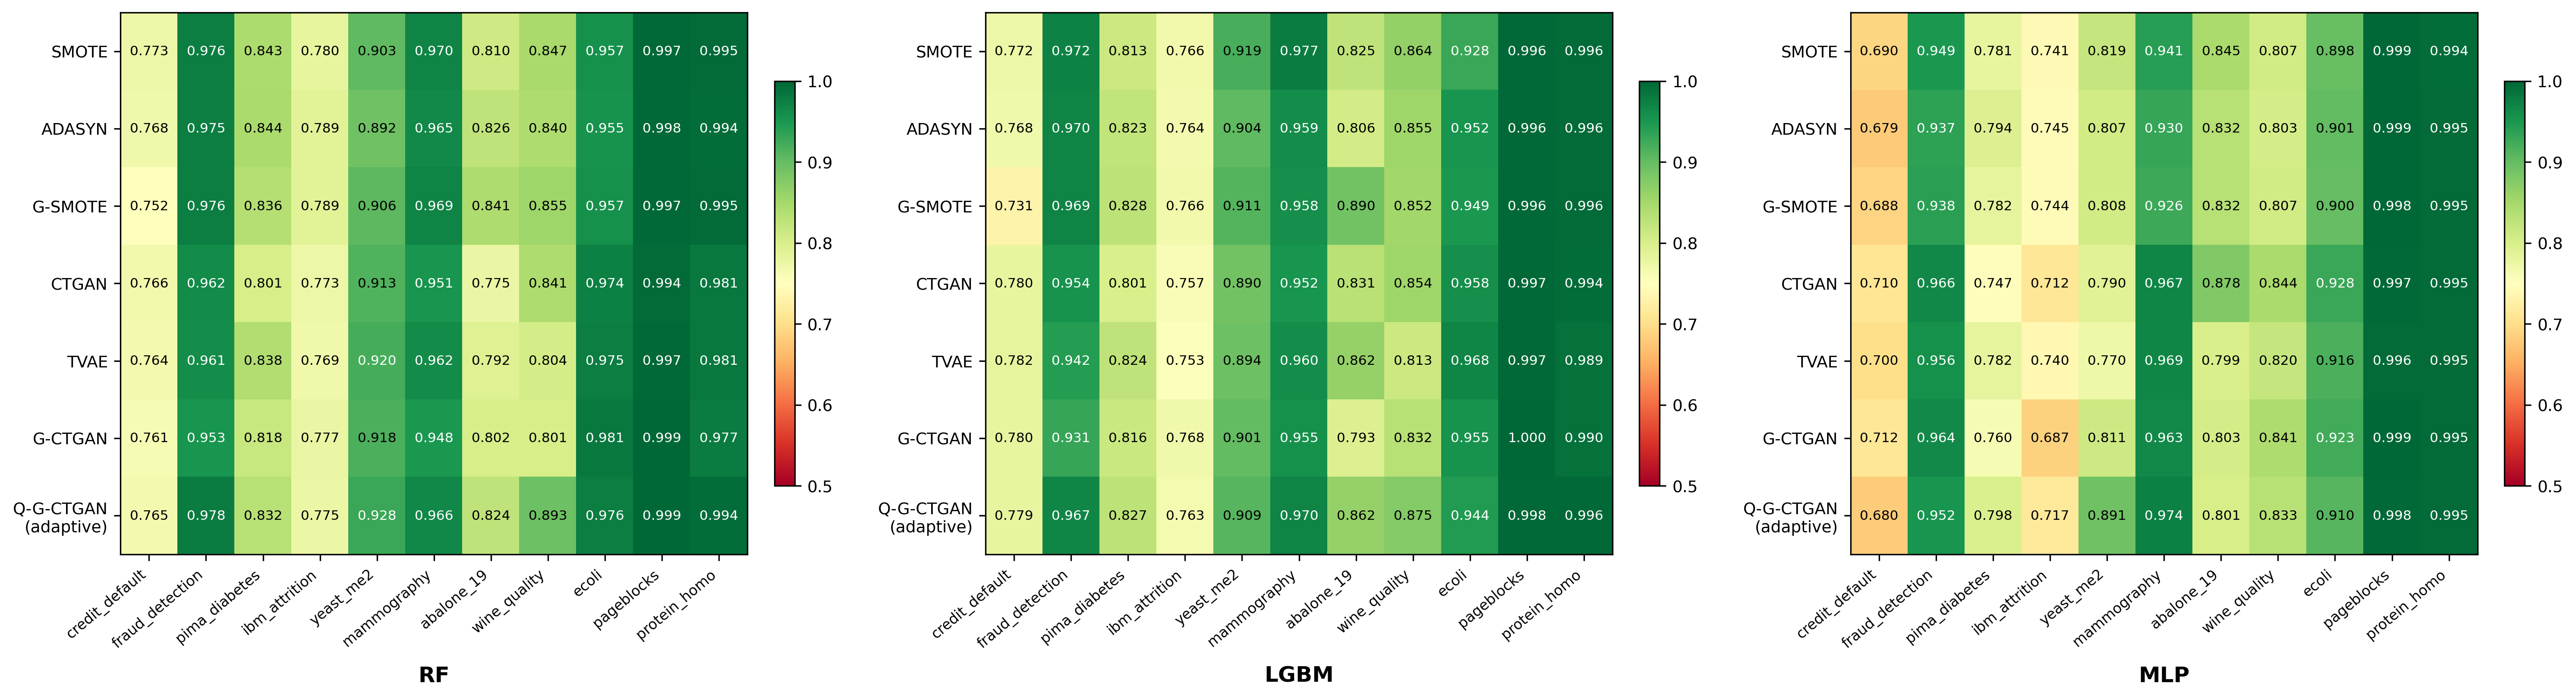


Friedman [RF]: χ²=15.0636  p=0.0198  ✓ Reject H0
  Wilcoxon vs SMOTE                  | Δ=+0.0073  W=23.0  p=0.4131  
  Wilcoxon vs ADASYN                 | Δ=+0.0076  W=20.5  p=0.4752  
  Wilcoxon vs G-SMOTE                | Δ=+0.0053  W=25.0  p=0.5195  
  Wilcoxon vs CTGAN                  | Δ=+0.0179  W=1.0  p=0.0020  * p<0.05
  Wilcoxon vs TVAE                   | Δ=+0.0151  W=6.0  p=0.0137  * p<0.05
  Wilcoxon vs G-CTGAN                | Δ=+0.0176  W=7.0  p=0.0186  * p<0.05

Friedman [LGBM]: χ²=5.7362  p=0.4534  Fail to reject
  Wilcoxon vs SMOTE                  | Δ=+0.0058  W=19.0  p=0.2402  
  Wilcoxon vs ADASYN                 | Δ=+0.0091  W=13.0  p=0.0830  
  Wilcoxon vs G-SMOTE                | Δ=+0.0043  W=32.5  p=1.0000  
  Wilcoxon vs CTGAN                  | Δ=+0.0114  W=7.0  p=0.0186  * p<0.05
  Wilcoxon vs TVAE                   | Δ=+0.0099  W=13.0  p=0.0830  
  Wilcoxon vs G-CTGAN                | Δ=+0.0155  W=12.0  p=0.0674  

Friedman [MLP]: χ²=5.7463  p=0.4522  Fa

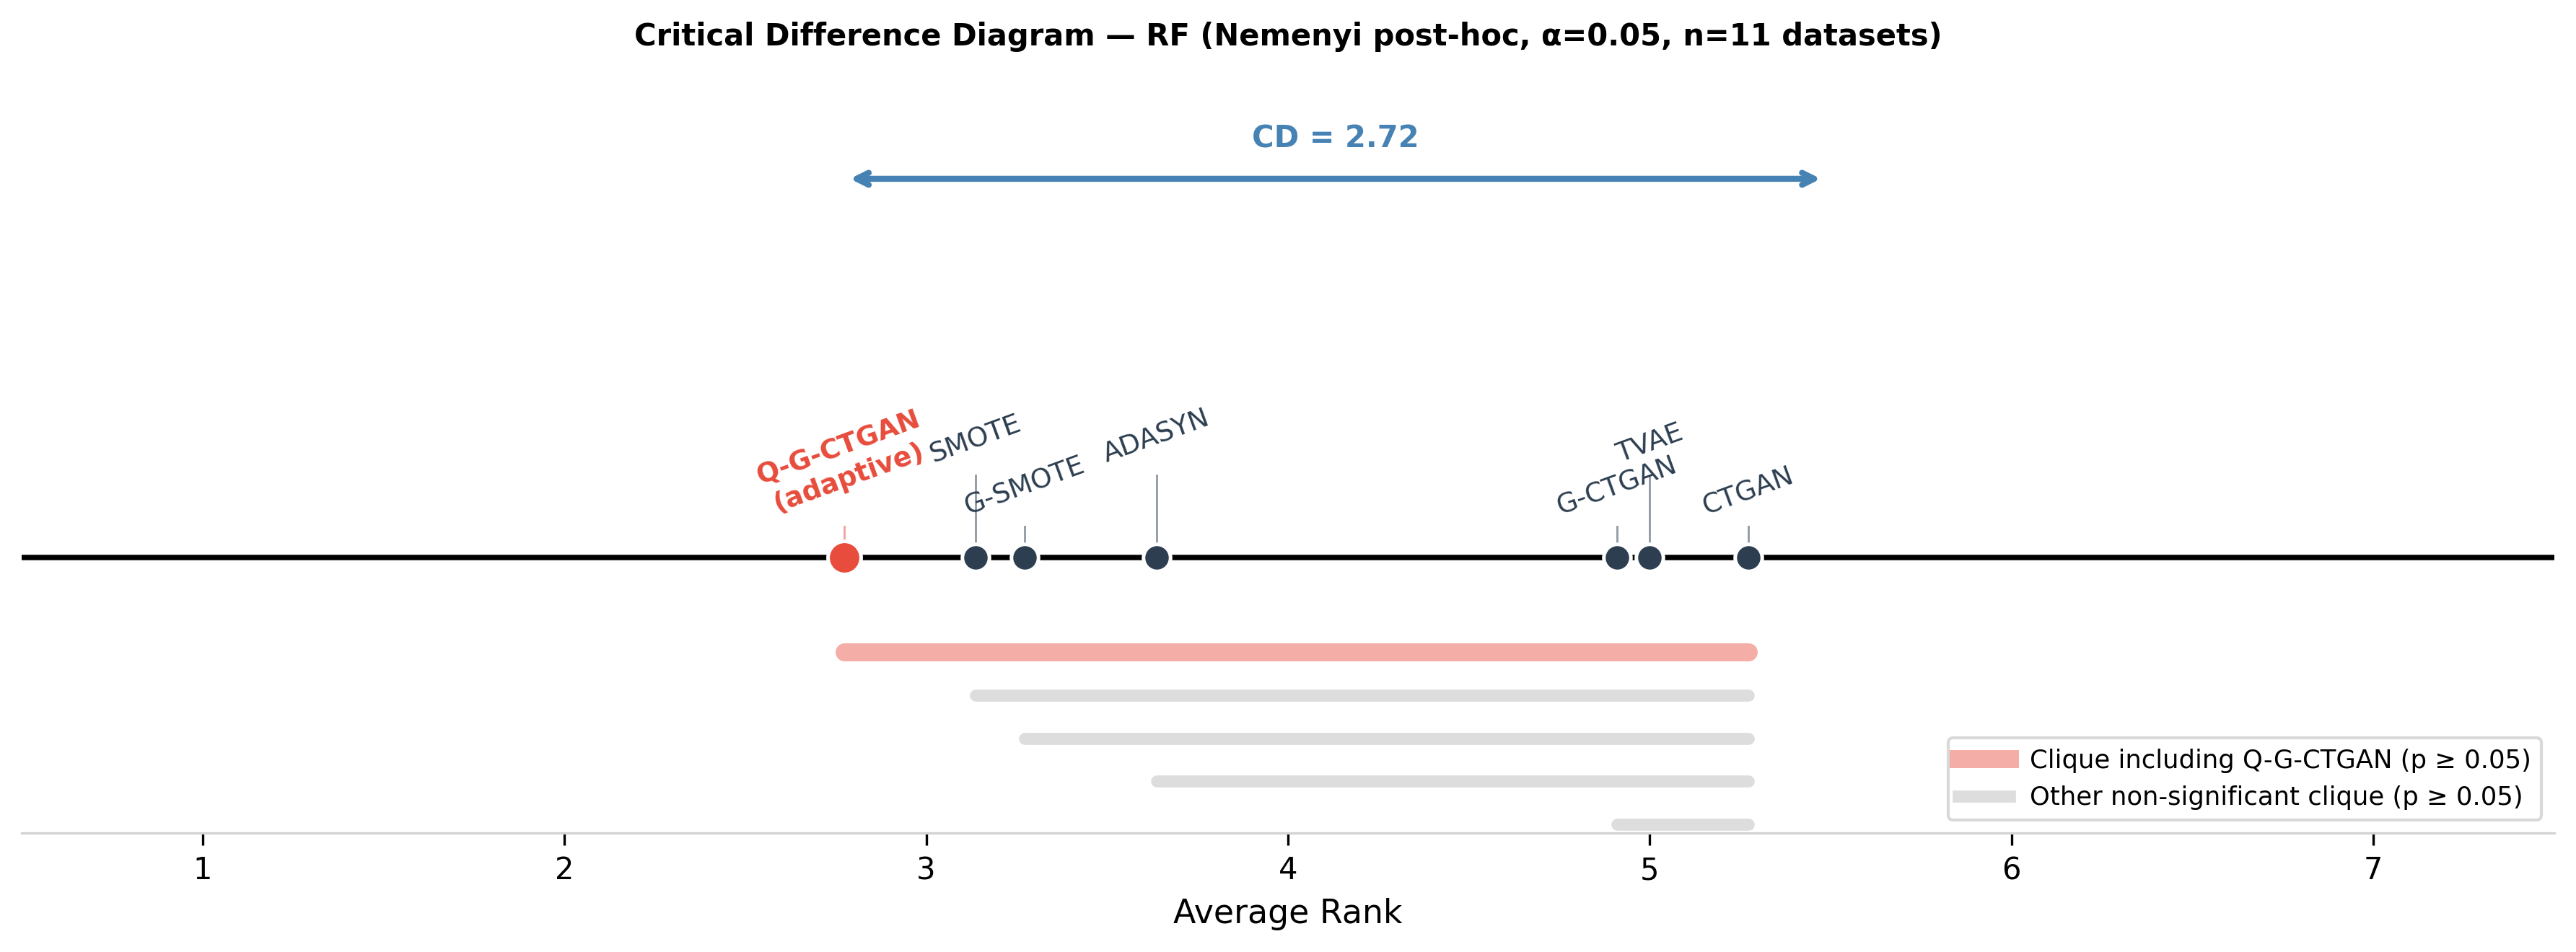


Nemenyi [LGBM] saved → ./results\04_nemenyi_lgbm.csv
Figure saved → ./results\04_cd_diagram_lgbm.png


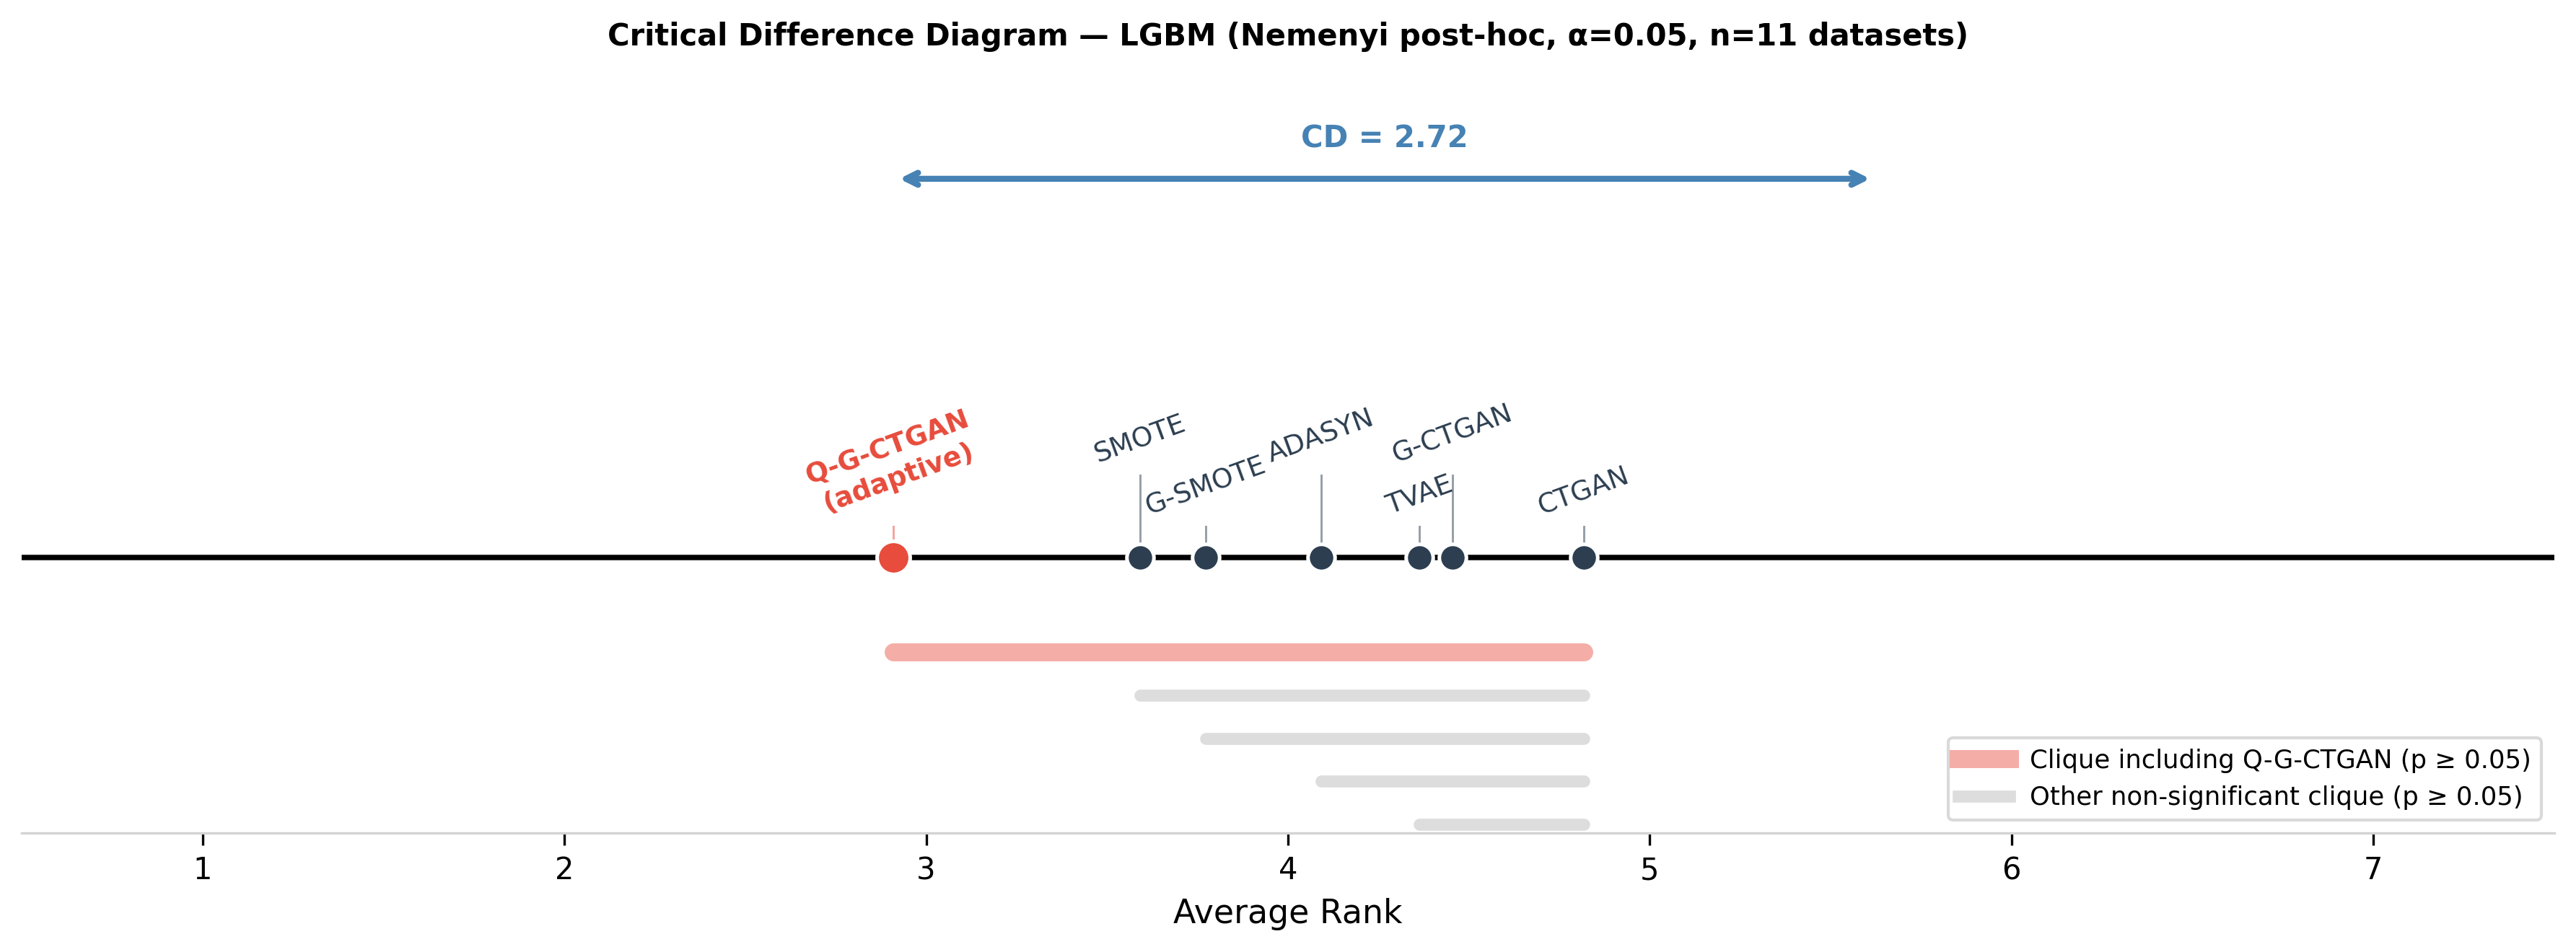


Nemenyi [MLP] saved → ./results\04_nemenyi_mlp.csv
Figure saved → ./results\04_cd_diagram_mlp.png


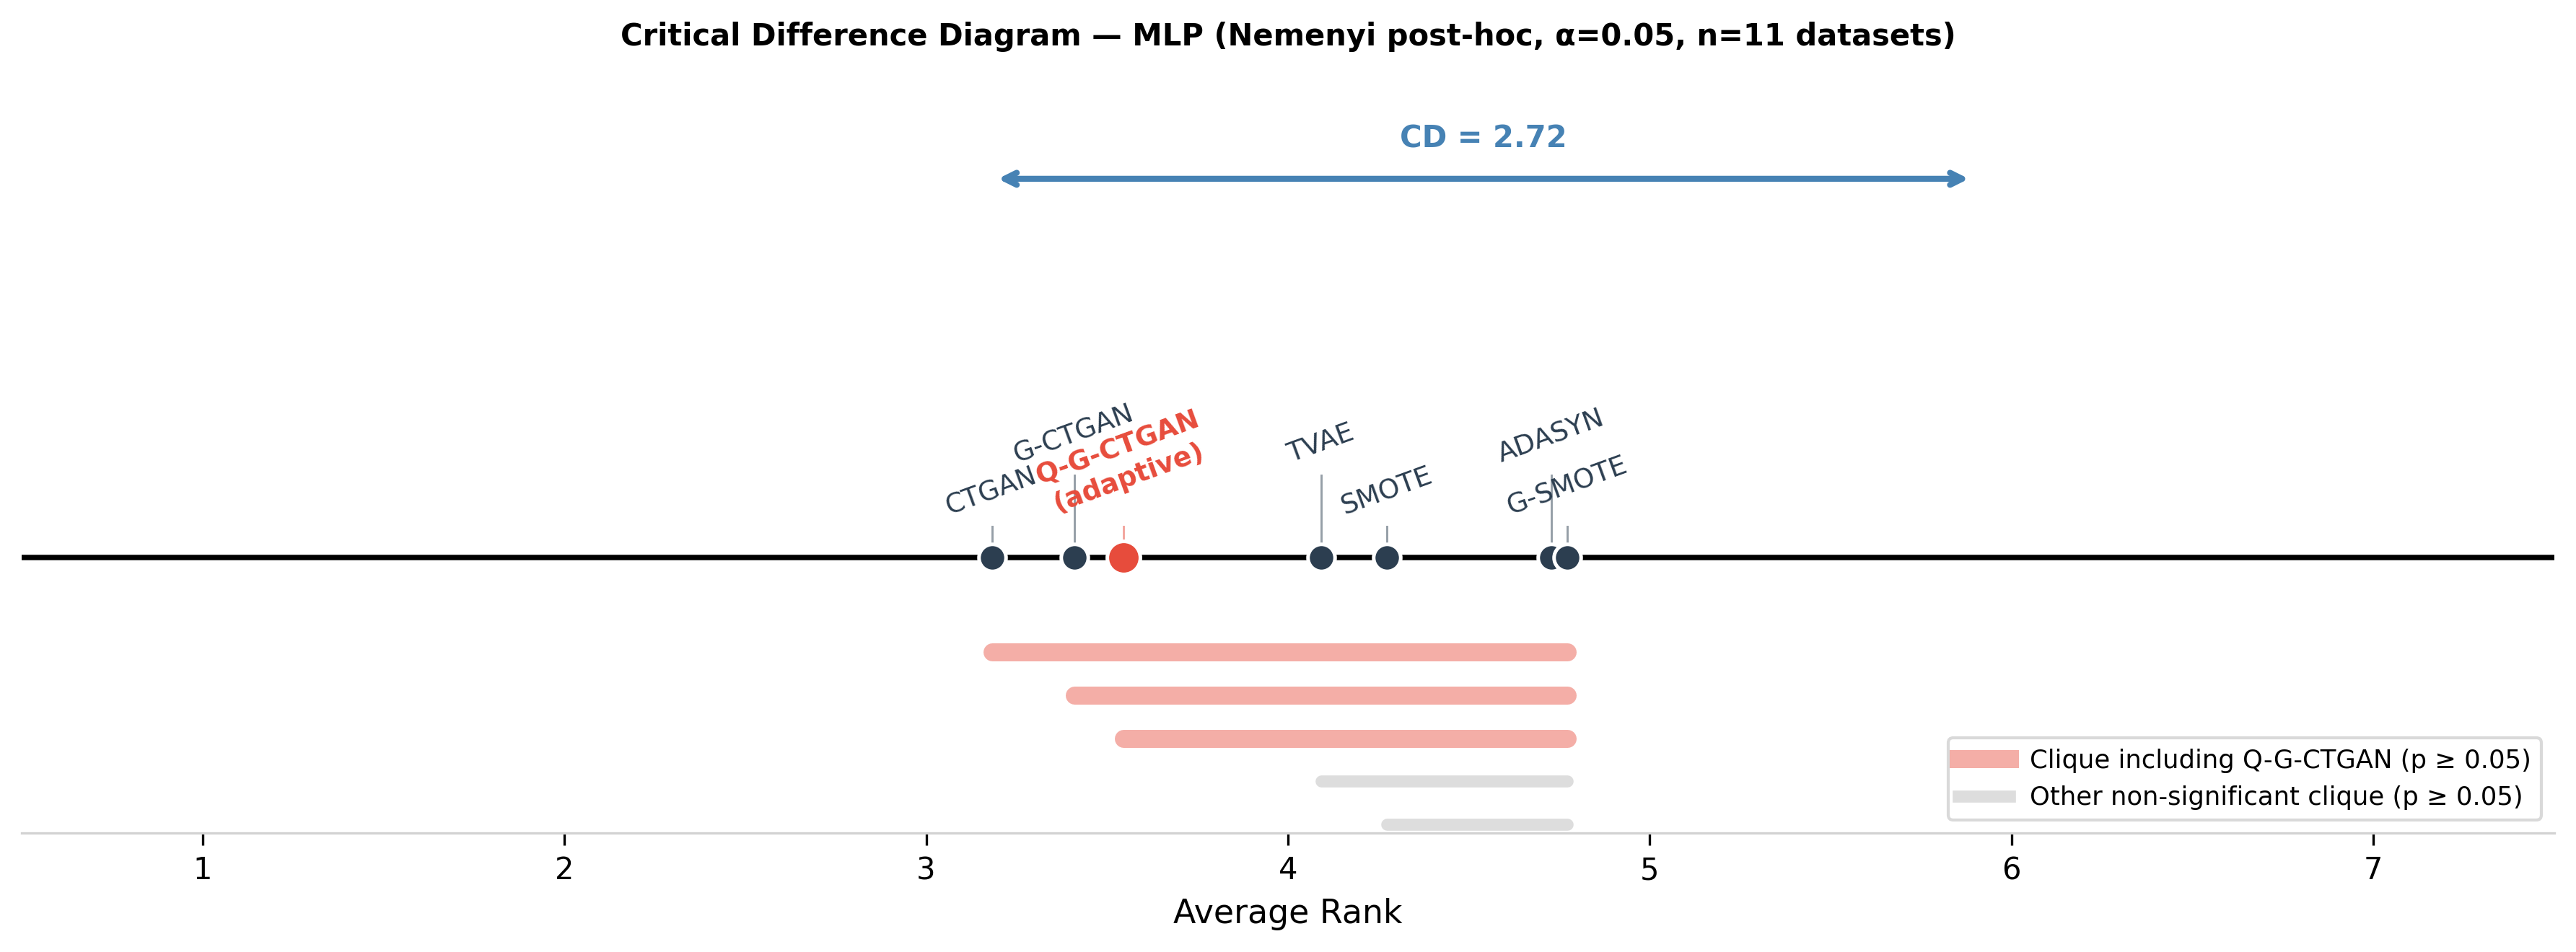


Ablation — Quality Indicator Contribution (RF, mean AUC):
  full     : 0.9026 ± 0.0884
  density  : 0.8983 ± 0.0882
  sep      : 0.8999 ± 0.0901
  lof      : 0.9032 ± 0.0848
Figure saved → ./results\04_ablation_quality.png


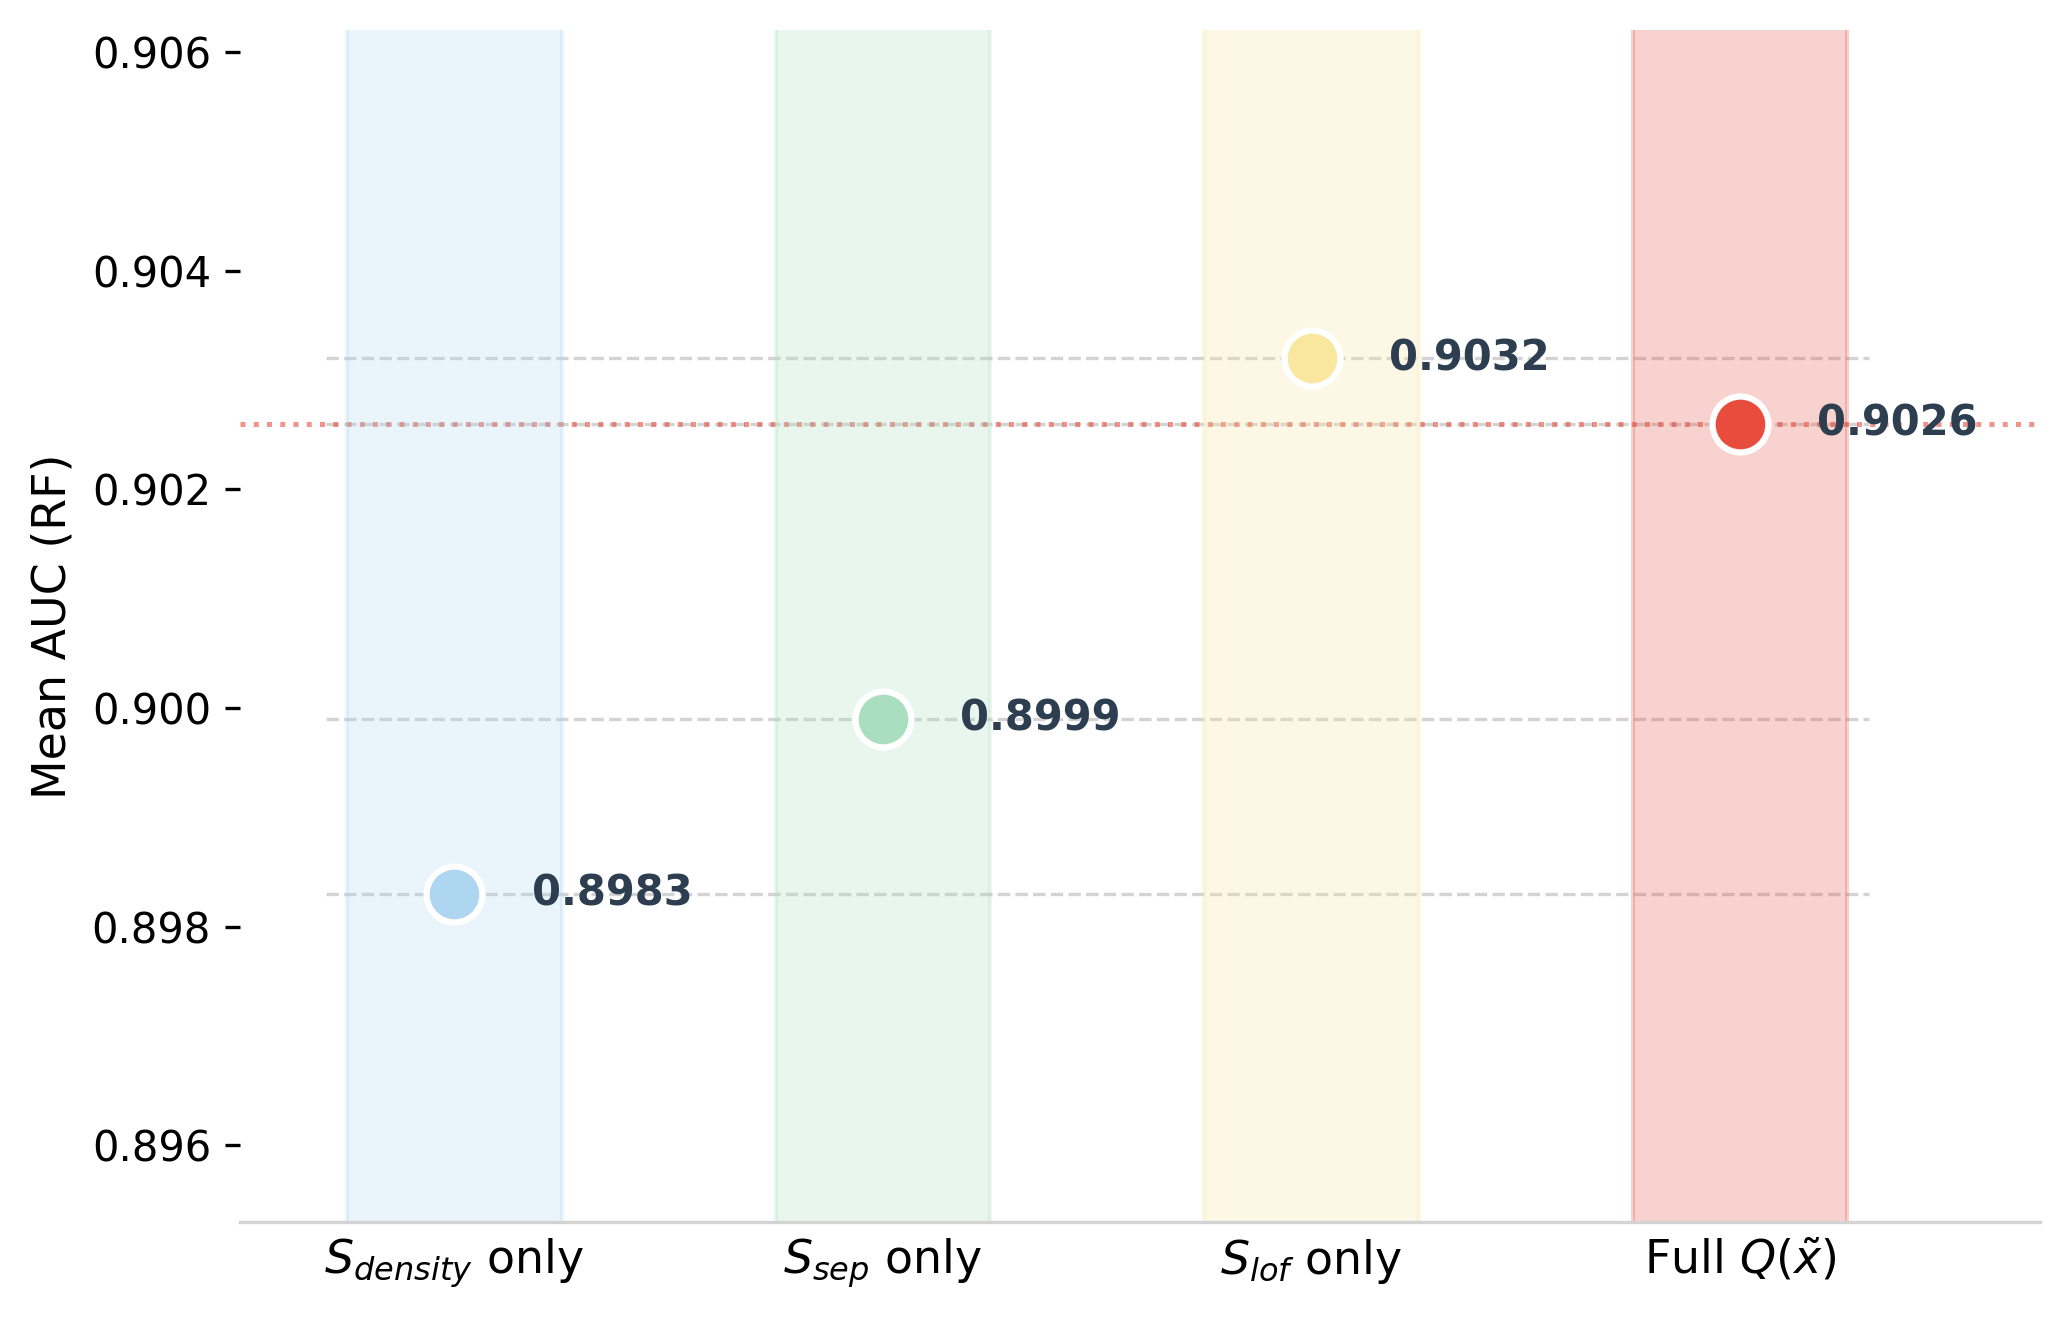


MMD Summary (mean per α mode):
                    mmd_before  mmd_after  mmd_reduction
alpha_mode                                              
Q-G-CTGAN_a0.1          0.0469     0.0482        -0.0014
Q-G-CTGAN_a0.2          0.0515     0.0534        -0.0019
Q-G-CTGAN_a0.3          0.0474     0.0462         0.0012
Q-G-CTGAN_adaptive      0.0451     0.0454        -0.0004

Overall improvement rate : 54.5%
Figure saved → ./results\04_mmd_summary.png


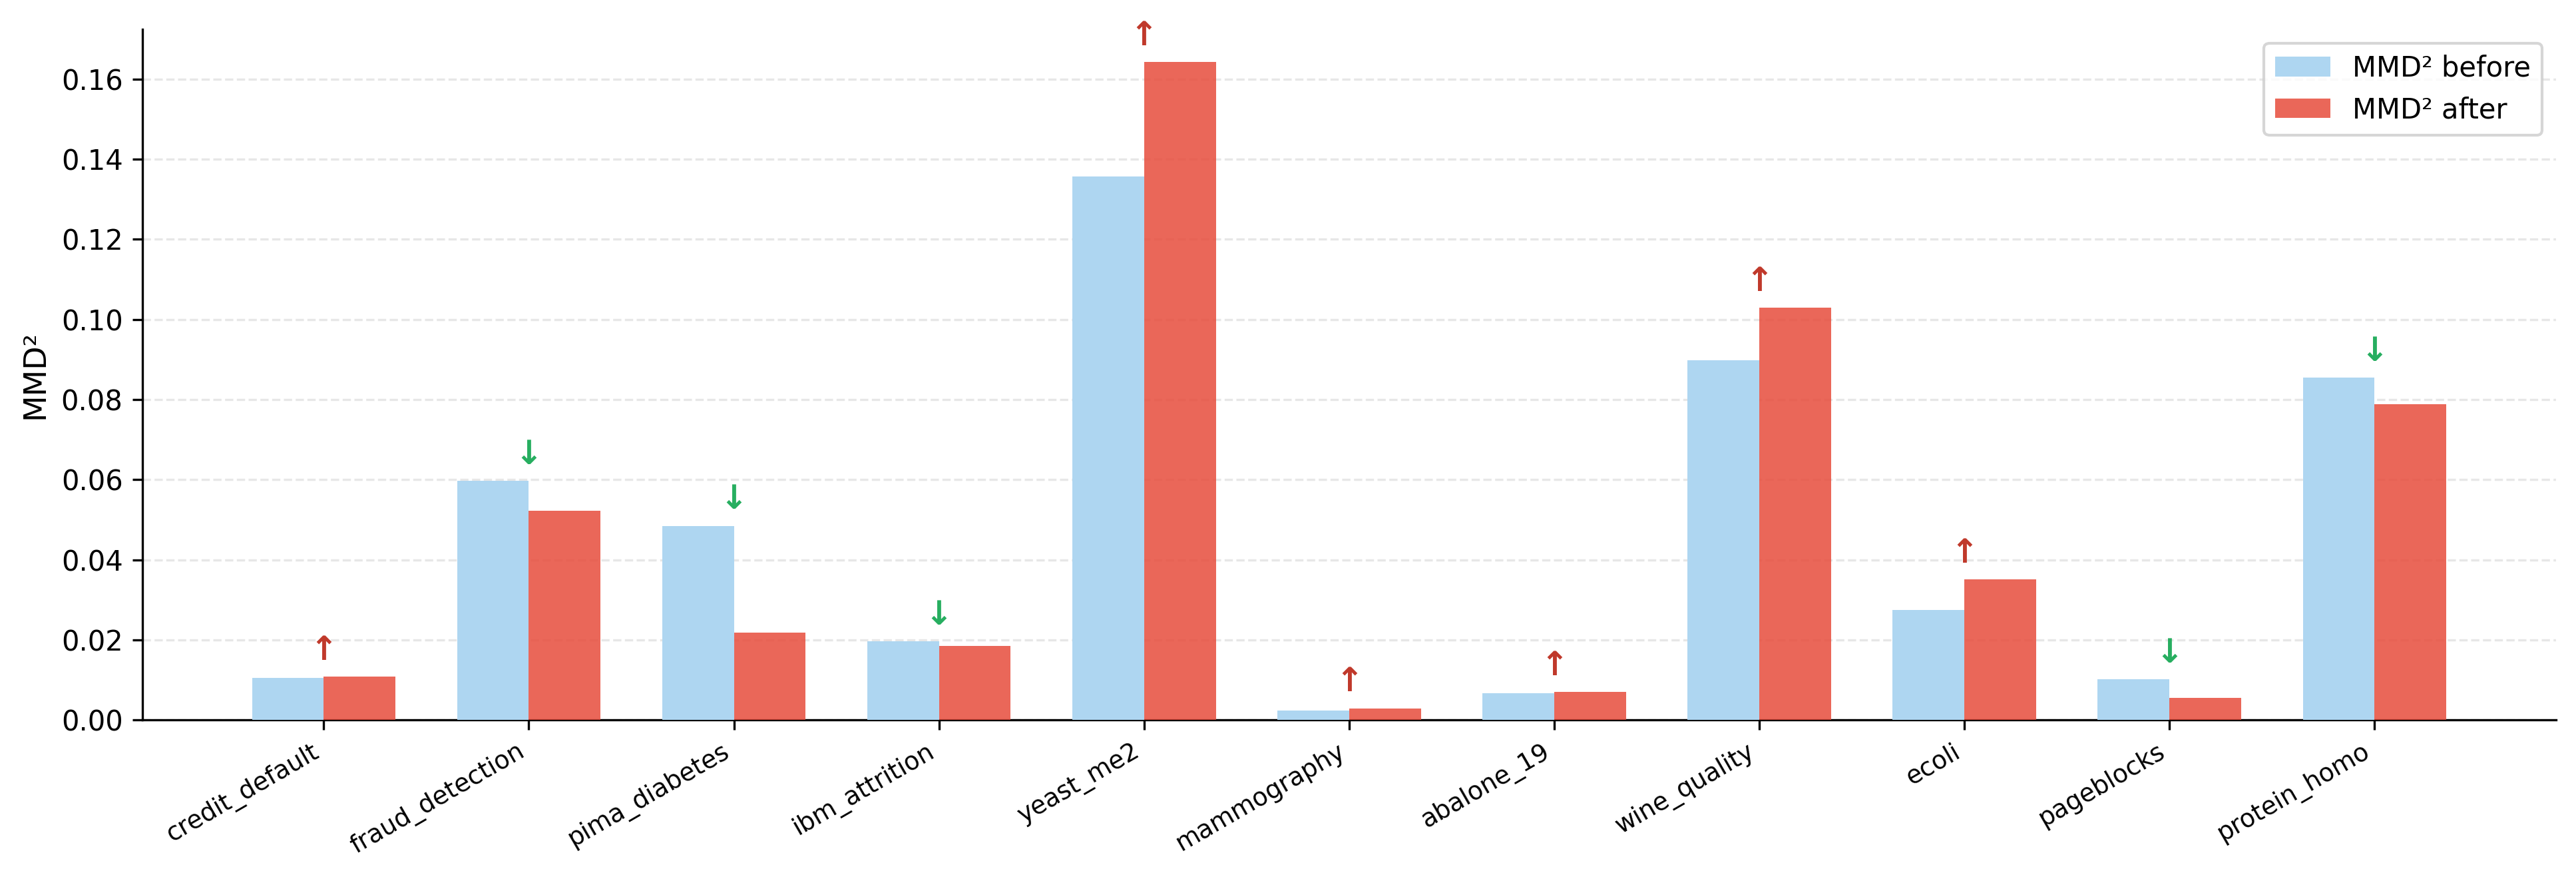


── Mean Rank (lower = better, per dataset×classifier) ──
classifier          LGBM   MLP    RF  overall
method                                       
Q-G-CTGAN_adaptive  2.91  3.55  2.77     3.08
SMOTE               3.59  4.27  3.14     3.67
G-SMOTE             3.77  4.77  3.27     3.94
ADASYN              4.09  4.73  3.64     4.15
G-CTGAN             4.45  3.41  4.91     4.26
CTGAN               4.82  3.18  5.27     4.42
TVAE                4.36  4.09  5.00     4.48

Ranking table saved → ./results\04_method_ranking.csv
Figure saved → ./results\04_figure3_adaptive_alpha.png


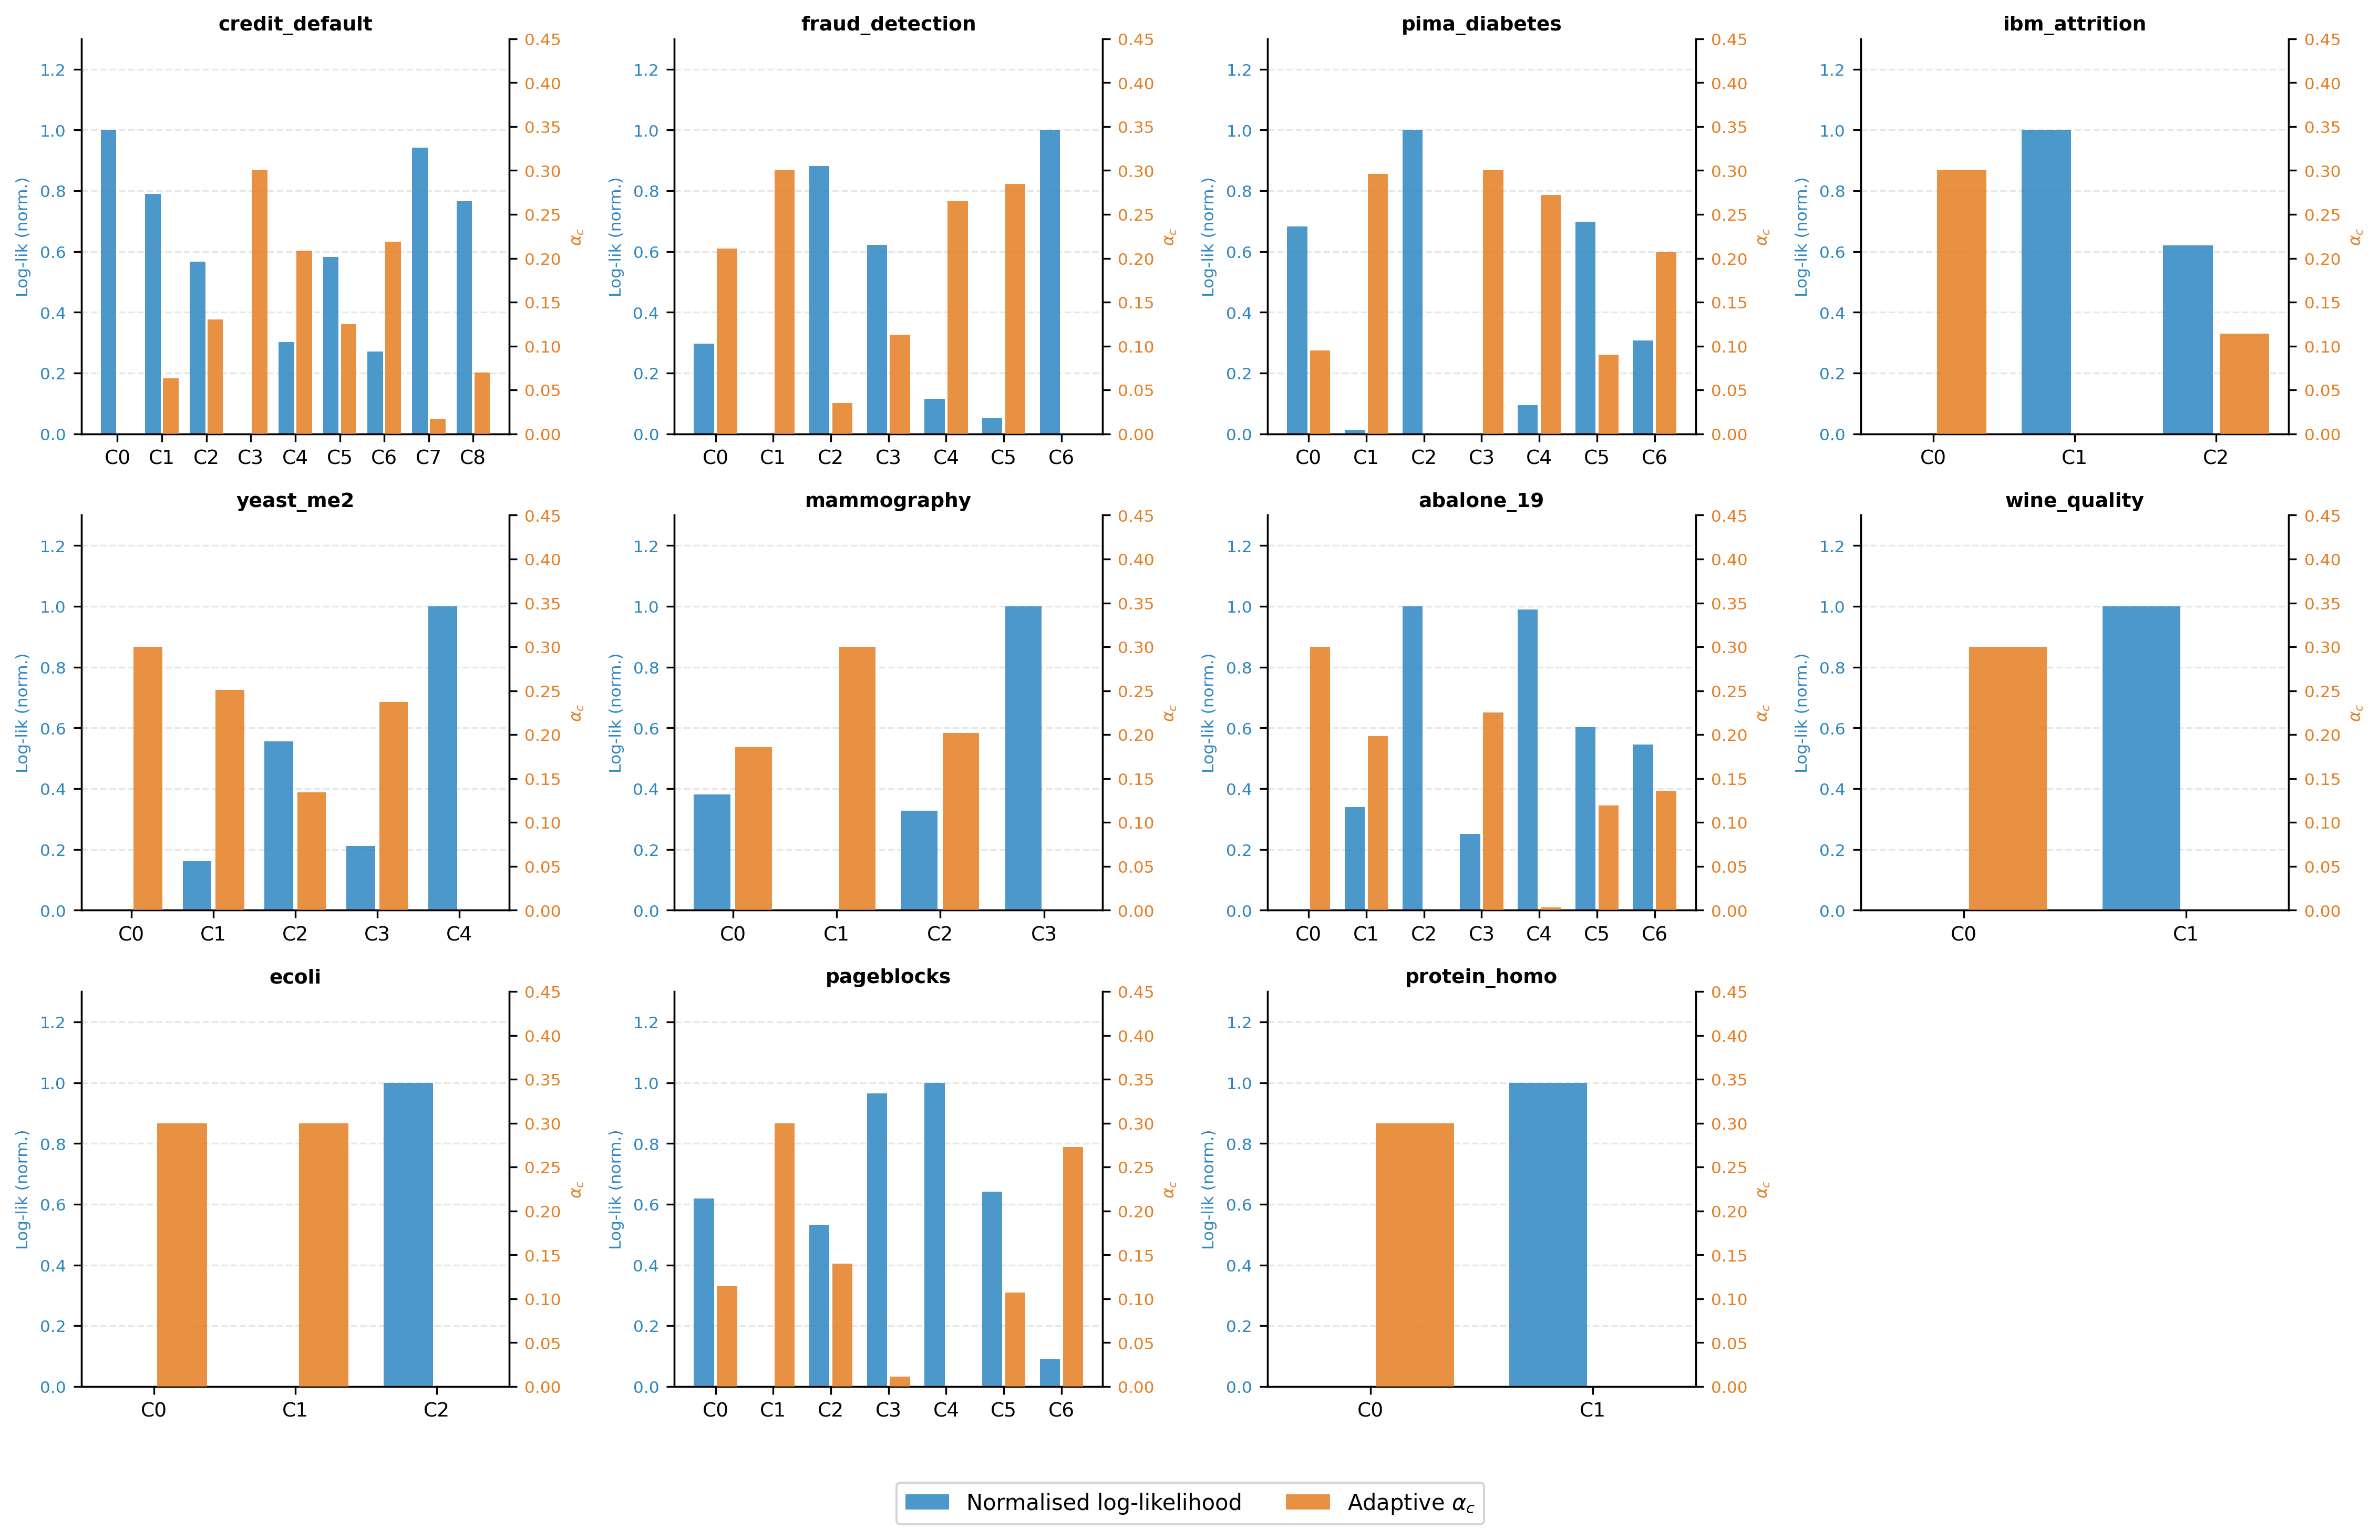

Figure saved → ./results\04_figure4_tsne.png


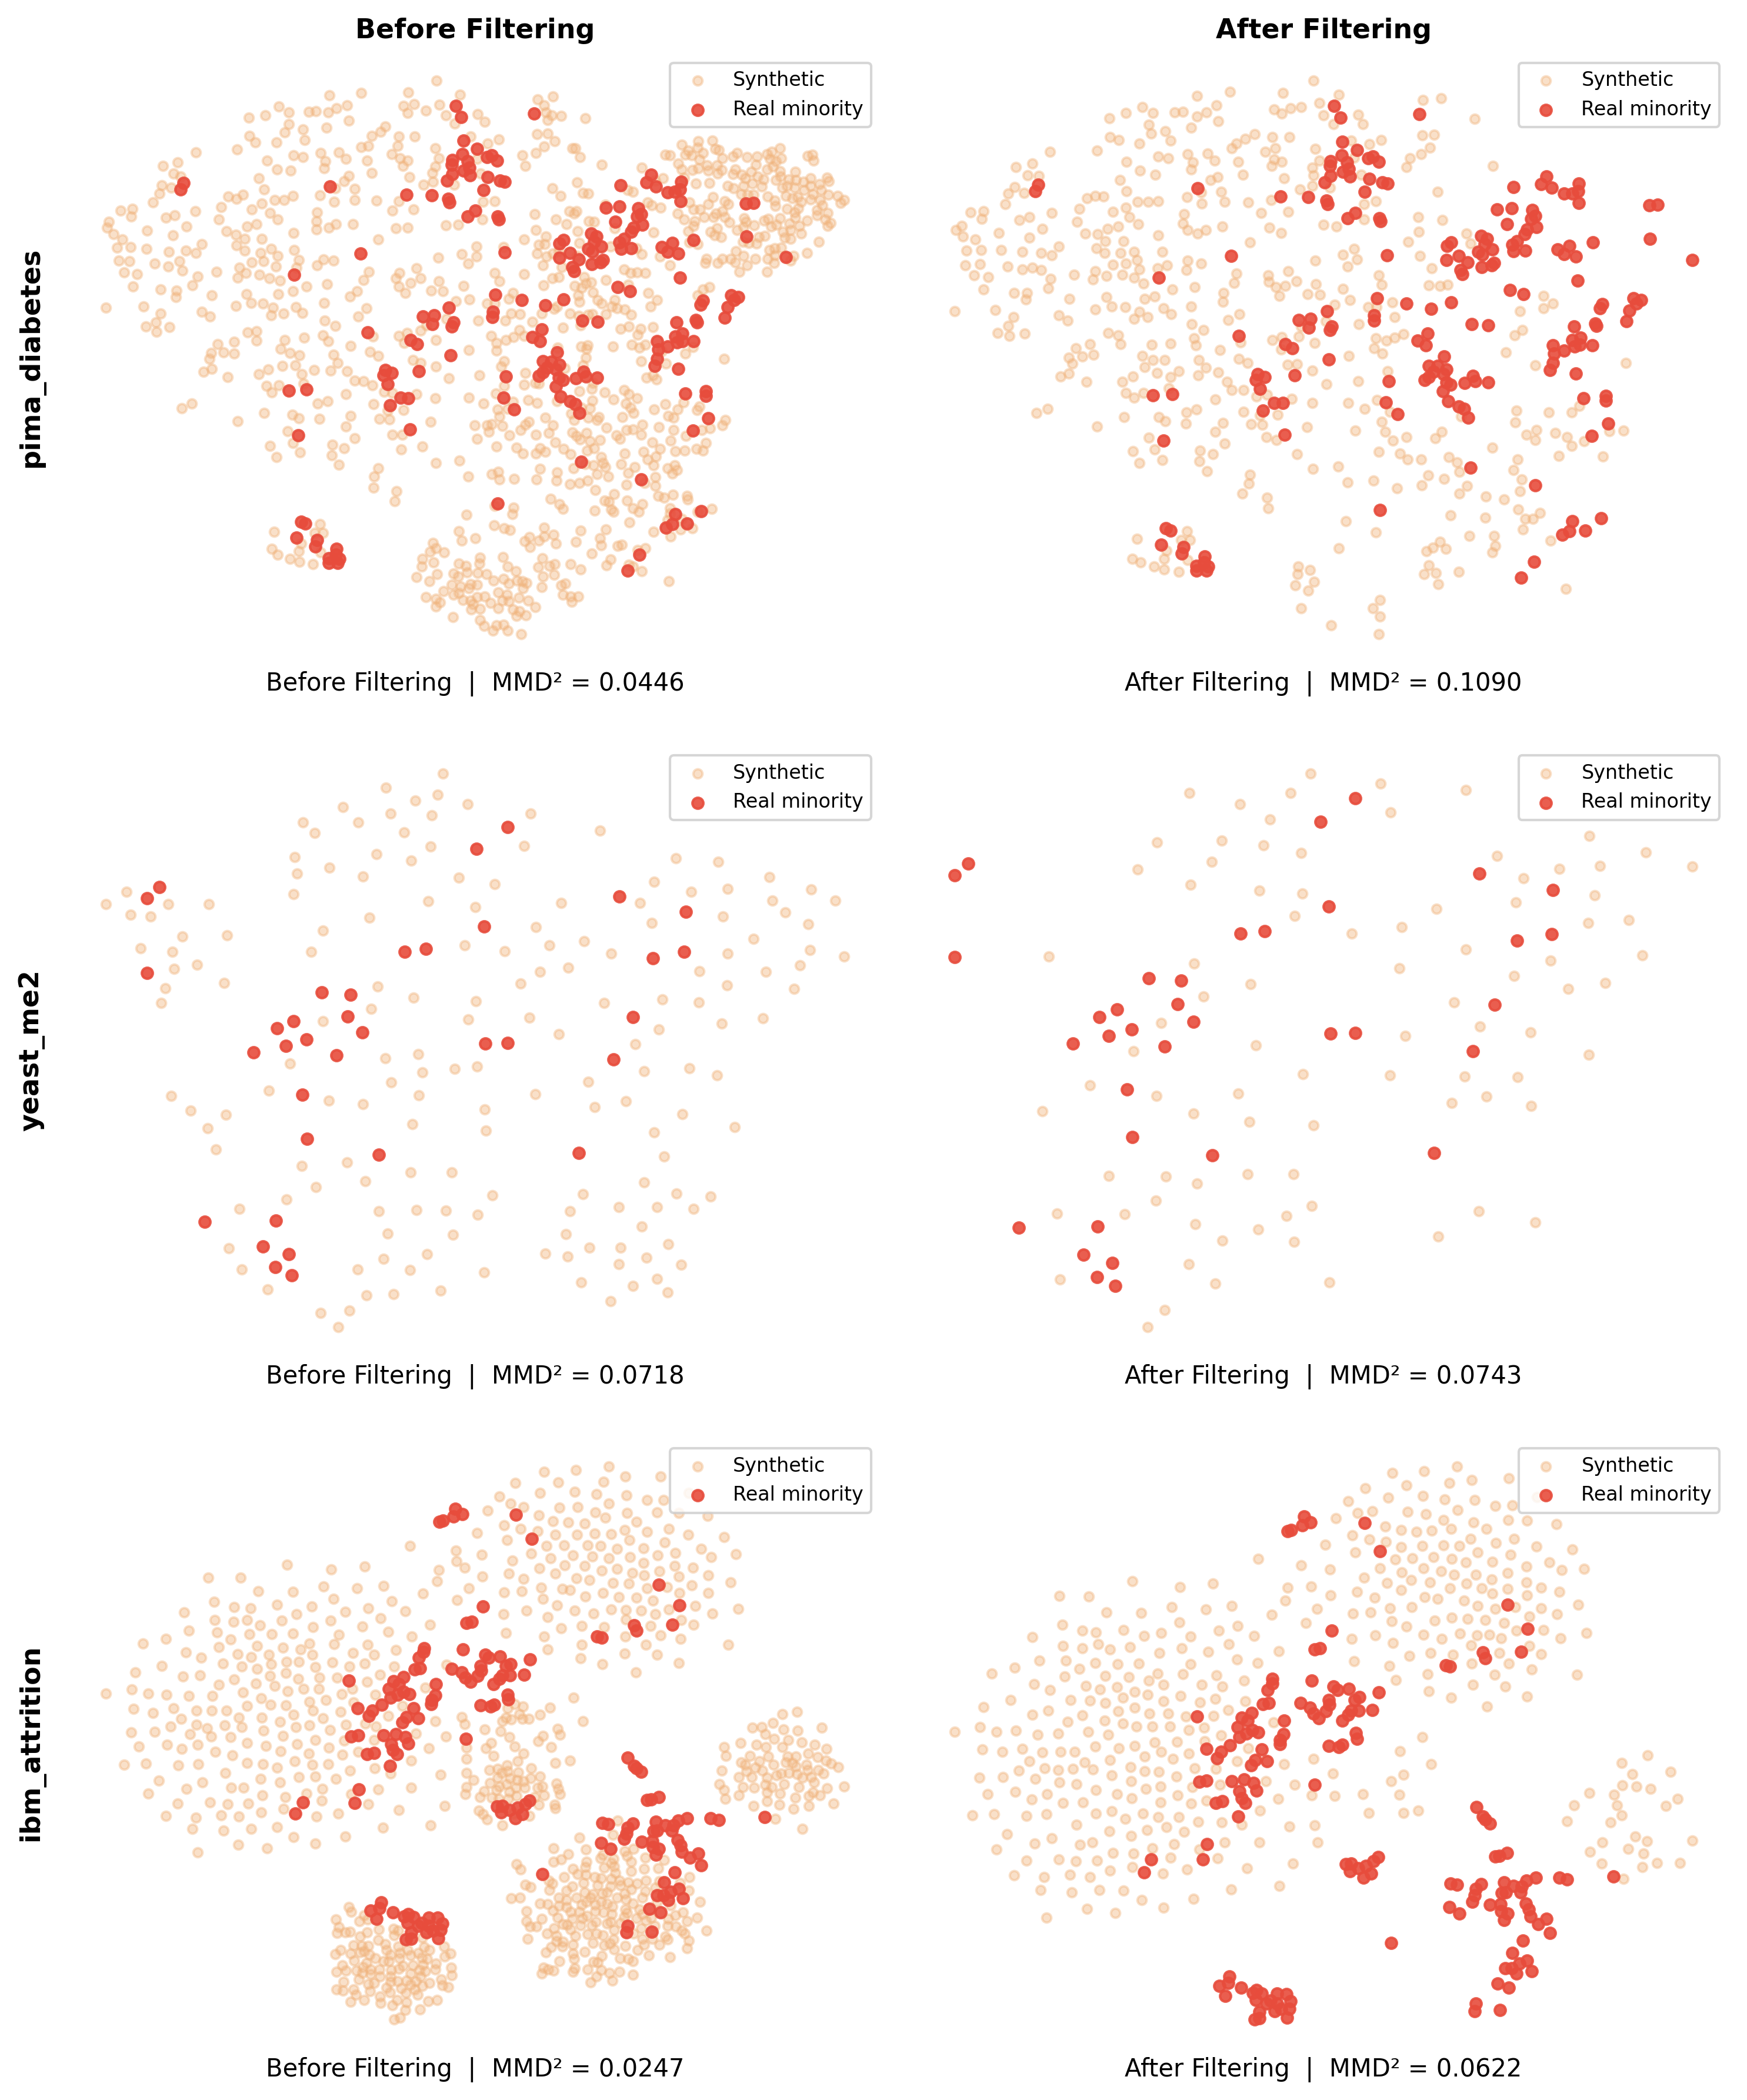


Analysis complete. All figures and tables saved to ./results/


In [15]:
# 04. Analysis — Combined Comparison, Statistical Tests, Paper Figures
#
# Reads:
#   results/02_baselines_results.csv
#   results/03_qgctgan_results.csv
#   results/03_ablation_quality.csv
#   results/03_qgctgan_mmd.csv
#
# Writes:
#   results/04_combined_comparison.csv
#   results/04_auc_table_rf.csv / lgbm / mlp
#   results/04_f1_table_rf.csv  / lgbm / mlp
#   results/04_statistical_tests.csv
#   results/04_auc_heatmap.png
#   results/04_cd_diagram_rf/lgbm/mlp.png
#   results/04_ablation_quality.png
#   results/04_mmd_summary.png
#   results/04_figure3_adaptive_alpha.png
#   results/04_figure4_tsne.png


# ════════════════════════════════════════════════════════════
## 0. Setup
# ════════════════════════════════════════════════════════════

import os
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "figure.dpi"      : 300,
    "savefig.dpi"     : 300,
    "font.size"       : 10,
    "axes.titlesize"  : 11,
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
    "legend.fontsize" : 10,
    "font.family"     : "sans-serif",
    "pdf.fonttype"    : 42,
    "ps.fonttype"     : 42,
})

def save_fig(fig, path_no_ext):
    """Save figure as PNG (300 dpi)."""
    out = path_no_ext + ".png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"Figure saved → {out}")

RESULTS_DIR  = "./results"
RANDOM_STATE = 42

DATASET_NAMES = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

METHOD_ORDER = [
    "None", "SMOTE", "ADASYN", "G-SMOTE",
    "CTGAN", "TVAE", "G-CTGAN", "Q-G-CTGAN_adaptive",
]

METHOD_LABELS = {
    "None"               : "None",
    "SMOTE"              : "SMOTE",
    "ADASYN"             : "ADASYN",
    "G-SMOTE"            : "G-SMOTE",
    "CTGAN"              : "CTGAN",
    "TVAE"               : "TVAE",
    "G-CTGAN"            : "G-CTGAN",
    "Q-G-CTGAN_adaptive" : "Q-G-CTGAN\n(adaptive)",
}

CLASSIFIERS = ["RF", "LGBM", "MLP"]

print("Setup complete.")


# ════════════════════════════════════════════════════════════
## 1. Load & Merge Results
# ════════════════════════════════════════════════════════════

base_df = pd.read_csv(os.path.join(RESULTS_DIR, "02_baselines_results.csv"))
qg_df   = pd.read_csv(os.path.join(RESULTS_DIR, "03_qgctgan_results.csv"))

qg_best = qg_df[qg_df["oversampling"] == "Q-G-CTGAN_adaptive"].copy()

shared_cols = [c for c in base_df.columns if c in qg_best.columns]
combined    = pd.concat(
    [base_df[shared_cols], qg_best[shared_cols]], ignore_index=True
)

combined.to_csv(os.path.join(RESULTS_DIR, "04_combined_comparison.csv"), index=False)
print(f"Combined rows : {len(combined)}")
print(f"Methods found : {combined['oversampling'].unique().tolist()}")


# ════════════════════════════════════════════════════════════
## 2. Per-Dataset AUC / F1 Tables
# ════════════════════════════════════════════════════════════

def build_per_dataset_table(metric="AUC"):
    tables = {}
    for clf in CLASSIFIERS:
        sub = combined[combined["classifier"] == clf]
        pivot = (
            sub.groupby(["dataset", "oversampling"])[metric]
            .mean().unstack()
            .reindex(index=DATASET_NAMES,
                     columns=[m for m in METHOD_ORDER
                               if m in sub["oversampling"].unique()])
        )
        tables[clf] = pivot
        save_path = os.path.join(RESULTS_DIR,
                                 f"04_{metric.lower()}_table_{clf.lower()}.csv")
        pivot.round(4).to_csv(save_path)
        print(f"  Saved → {save_path}")
    return tables

print("\nBuilding per-dataset AUC tables...")
auc_tables = build_per_dataset_table("AUC")

print("\nBuilding per-dataset F1 tables...")
f1_tables  = build_per_dataset_table("F1")

print("\n── Mean AUC (all datasets) ──")
mean_auc = (
    combined.groupby(["oversampling", "classifier"])["AUC"]
    .mean().round(4).unstack()
    .reindex([m for m in METHOD_ORDER if m in combined["oversampling"].unique()])
)
print(mean_auc.to_string())

print("\n── Mean F1 (all datasets) ──")
mean_f1 = (
    combined.groupby(["oversampling", "classifier"])["F1"]
    .mean().round(4).unstack()
    .reindex([m for m in METHOD_ORDER if m in combined["oversampling"].unique()])
)
print(mean_f1.to_string())


# ════════════════════════════════════════════════════════════
## 3. AUC Heatmap
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

for ax, clf in zip(axes, CLASSIFIERS):
    tbl = auc_tables[clf].T   # methods × datasets

    # 표시용 라벨 변환
    row_labels = [METHOD_LABELS.get(m, m) for m in tbl.index]

    im = ax.imshow(tbl.values.astype(float),
                   aspect="auto", cmap="RdYlGn",
                   vmin=0.5, vmax=1.0)

    ax.set_xticks(range(len(tbl.columns)))
    ax.set_xticklabels(tbl.columns, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(tbl.index)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_xlabel(clf, fontsize=12, fontweight="bold", labelpad=8)

    for i in range(len(tbl.index)):
        for j in range(len(tbl.columns)):
            val = tbl.values[i, j]
            if not np.isnan(val):
                txt_color = "white" if (val < 0.6 or val > 0.92) else "black"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        fontsize=7.5, color=txt_color)

    cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cbar.ax.tick_params(labelsize=9)

plt.tight_layout(w_pad=2.5)
save_fig(fig, os.path.join(RESULTS_DIR, "04_auc_heatmap"))
plt.show()


# ════════════════════════════════════════════════════════════
## 4. Statistical Tests
# ════════════════════════════════════════════════════════════

from scipy.stats import wilcoxon, friedmanchisquare

stat_rows = []

for clf in CLASSIFIERS:
    sub = combined[combined["classifier"] == clf]

    pivot = (
        sub.groupby(["dataset", "oversampling"])["AUC"]
        .mean().unstack()
        .reindex(index=DATASET_NAMES,
                 columns=[m for m in METHOD_ORDER
                           if m in sub["oversampling"].unique()])
        .dropna(axis=1, how="all")
    )

    methods = pivot.columns.tolist()

    friedman_data = [pivot[m].dropna().values for m in methods]
    min_len = min(len(d) for d in friedman_data)
    friedman_data = [d[:min_len] for d in friedman_data]

    try:
        f_stat, f_p = friedmanchisquare(*friedman_data)
    except Exception:
        f_stat, f_p = np.nan, np.nan

    stat_rows.append({
        "test"       : "Friedman",
        "classifier" : clf,
        "method_A"   : "all",
        "method_B"   : "all",
        "statistic"  : round(f_stat, 4) if not np.isnan(f_stat) else None,
        "p_value"    : round(f_p,    4) if not np.isnan(f_p)    else None,
        "significant": f_p < 0.05 if not np.isnan(f_p) else None,
    })
    print(f"\nFriedman [{clf}]: χ²={f_stat:.4f}  p={f_p:.4f}  "
          f"{'✓ Reject H0' if f_p < 0.05 else 'Fail to reject'}")

    if "Q-G-CTGAN_adaptive" not in pivot.columns:
        print(f"  Q-G-CTGAN_adaptive not found for {clf}, skipping Wilcoxon.")
        continue

    q_scores = pivot["Q-G-CTGAN_adaptive"].values

    for base in methods:
        if base == "Q-G-CTGAN_adaptive":
            continue
        b_scores = pivot[base].values
        mask = ~(np.isnan(q_scores) | np.isnan(b_scores))
        q_v, b_v = q_scores[mask], b_scores[mask]

        if len(q_v) < 5:
            w_stat, w_p = np.nan, np.nan
        else:
            try:
                w_stat, w_p = wilcoxon(q_v, b_v, alternative="two-sided")
            except Exception:
                w_stat, w_p = np.nan, np.nan

        delta = round(float(np.nanmean(q_v - b_v)), 4)
        wins  = int((q_v > b_v).sum())

        stat_rows.append({
            "test"       : "Wilcoxon",
            "classifier" : clf,
            "method_A"   : "Q-G-CTGAN_adaptive",
            "method_B"   : base,
            "statistic"  : round(w_stat, 4) if not np.isnan(w_stat) else None,
            "p_value"    : round(w_p,    4) if not np.isnan(w_p)    else None,
            "delta_mean" : delta,
            "wins"       : f"{wins}/{len(q_v)}",
            "significant": w_p < 0.05 if not np.isnan(w_p) else None,
        })
        sig = "* p<0.05" if (not np.isnan(w_p) and w_p < 0.05) else ""
        print(f"  Wilcoxon vs {base:<22} | Δ={delta:+.4f}  "
              f"W={w_stat:.1f}  p={w_p:.4f}  {sig}")

stat_df = pd.DataFrame(stat_rows)
stat_path = os.path.join(RESULTS_DIR, "04_statistical_tests.csv")
stat_df.to_csv(stat_path, index=False)
print(f"\nStatistical tests saved → {stat_path}")


# ════════════════════════════════════════════════════════════
## 5. Nemenyi Post-hoc & Critical Difference Diagram
# ════════════════════════════════════════════════════════════

try:
    from scikit_posthocs import posthoc_nemenyi_friedman
    NEMENYI_AVAILABLE = True
except ImportError:
    NEMENYI_AVAILABLE = False
    print("scikit-posthocs not installed. pip install scikit-posthocs")

if NEMENYI_AVAILABLE:
    for clf in CLASSIFIERS:
        sub = combined[combined["classifier"] == clf]
        pivot = (
            sub.groupby(["dataset", "oversampling"])["AUC"]
            .mean().unstack()
            .reindex(index=DATASET_NAMES,
                     columns=[m for m in METHOD_ORDER
                               if m in sub["oversampling"].unique()])
            .dropna(axis=1, how="all")
        )
        pivot_clean = pivot.dropna()

        try:
            nemenyi_raw = posthoc_nemenyi_friedman(pivot_clean.values)
            nemenyi = pd.DataFrame(
                nemenyi_raw.values,
                index=pivot_clean.columns,
                columns=pivot_clean.columns,
            )

            nemenyi_path = os.path.join(RESULTS_DIR,
                                        f"04_nemenyi_{clf.lower()}.csv")
            nemenyi.round(4).to_csv(nemenyi_path)
            print(f"\nNemenyi [{clf}] saved → {nemenyi_path}")

            # Fix: "None" stored as NaN in oversampling column — restore label
            pivot_clean.columns = [
                "None" if (isinstance(c, float) and np.isnan(c)) else c
                for c in pivot_clean.columns
            ]
            nemenyi.index = pivot_clean.columns
            nemenyi.columns = pivot_clean.columns

            ranks        = pivot_clean.rank(axis=1, ascending=False).mean()
            ranks_sorted = ranks.sort_values()
            n_methods    = len(ranks_sorted)
            n_datasets   = len(pivot_clean)

            q_alpha_table = {2:1.960, 3:2.343, 4:2.569, 5:2.728,
                             6:2.850, 7:2.949, 8:3.031, 9:3.102, 10:3.164}
            q_alpha = q_alpha_table.get(n_methods, 3.164)
            CD = q_alpha * np.sqrt(n_methods * (n_methods + 1) / (6 * n_datasets))

            fig, ax = plt.subplots(figsize=(12, 4.5))

            ax.set_xlim(0.5, n_methods + 0.5)
            ax.set_ylim(-1.6, 2.8)
            ax.set_xlabel("Average Rank", fontsize=11)
            ax.set_xticks(range(1, n_methods + 1))

            # Rank axis line
            ax.axhline(0, color="black", linewidth=1.8, zorder=3)
            ax.set_yticks([])
            ax.spines[["top", "right", "left"]].set_visible(False)
            ax.spines["bottom"].set_color("lightgray")
            ax.tick_params(axis="x", labelsize=10, length=4)

            # ── Markers & alternating labels ──────────────────────────
            for idx, (method, rank) in enumerate(ranks_sorted.items()):
                is_ours = method == "Q-G-CTGAN_adaptive"
                color   = "#E74C3C" if is_ours else "#2C3E50"
                ms      = 11 if is_ours else 9

                ax.plot(rank, 0, "o",
                        color=color, markersize=ms,
                        zorder=5,
                        markeredgecolor="white", markeredgewidth=1.2)

                label = METHOD_LABELS.get(method, method)

                # Alternate label height to avoid overlap
                y_offset = 0.22 + 0.30 * (idx % 2)

                ax.text(rank, y_offset, label,
                        ha="center", va="bottom",
                        fontsize=9,
                        color=color,
                        fontweight="bold" if is_ours else "normal",
                        rotation=20,
                        linespacing=1.3)

                # Thin vertical tick from axis to label base
                ax.plot([rank, rank], [0.02, y_offset - 0.04],
                        color=color, linewidth=0.7, alpha=0.5, zorder=2)

            # ── CD bracket (from rank 1 leftmost) ─────────────────────
            cd_y     = 2.2
            rank_min = ranks_sorted.iloc[0]   # best rank (leftmost)
            ax.annotate("",
                        xy=(rank_min + CD, cd_y),
                        xytext=(rank_min, cd_y),
                        arrowprops=dict(arrowstyle="<->",
                                        color="steelblue",
                                        lw=2.0))
            ax.text(rank_min + CD / 2, cd_y + 0.18,
                    f"CD = {CD:.2f}",
                    ha="center", fontsize=10,
                    color="steelblue", fontweight="bold")

            # ── Clique bars — Q-G-CTGAN clique highlighted ────────────
            y_clique = -0.55
            drawn    = set()
            for m1 in ranks_sorted.index:
                clique = []
                for m2 in ranks_sorted.index:
                    if (m1, m2) not in drawn and nemenyi.loc[m1, m2] >= 0.05:
                        clique.append(m2)
                        drawn.add((m1, m2))
                        drawn.add((m2, m1))
                if len(clique) > 1:
                    clique_ranks  = [ranks_sorted[m] for m in clique]
                    contains_ours = "Q-G-CTGAN_adaptive" in clique
                    bar_color     = "#E74C3C" if contains_ours else "#AAAAAA"
                    bar_alpha     = 0.45     if contains_ours else 0.40
                    bar_lw        = 6        if contains_ours else 4
                    ax.plot([min(clique_ranks), max(clique_ranks)],
                            [y_clique, y_clique],
                            color=bar_color, linewidth=bar_lw,
                            alpha=bar_alpha, zorder=3,
                            solid_capstyle="round")
                    y_clique -= 0.25

            # ── Clique legend ──────────────────────────────────────────
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], color="#E74C3C", linewidth=6, alpha=0.45,
                       label="Clique including Q-G-CTGAN (p ≥ 0.05)"),
                Line2D([0], [0], color="#AAAAAA", linewidth=4, alpha=0.40,
                       label="Other non-significant clique (p ≥ 0.05)"),
            ]
            ax.legend(handles=legend_elements, fontsize=8.5,
                      loc="lower right", framealpha=0.85,
                      edgecolor="lightgray")

            ax.set_title(
                f"Critical Difference Diagram — {clf} "
                f"(Nemenyi post-hoc, α=0.05, n={n_datasets} datasets)",
                fontsize=10, fontweight="bold", pad=10
            )

            plt.tight_layout()
            save_fig(fig, os.path.join(RESULTS_DIR,
                                       f"04_cd_diagram_{clf.lower()}"))
            plt.show()

        except Exception as e:
            print(f"  Nemenyi [{clf}] failed: {e}")


# ════════════════════════════════════════════════════════════
## 6. Ablation Quality Indicator Summary
# ════════════════════════════════════════════════════════════

abl_path = os.path.join(RESULTS_DIR, "03_ablation_quality.csv")
if os.path.exists(abl_path):
    abl_df   = pd.read_csv(abl_path)
    abl_mean = abl_df.groupby("weight_mode")["AUC"].mean().round(4)
    abl_std  = abl_df.groupby("weight_mode")["AUC"].std().round(4)

    print("\nAblation — Quality Indicator Contribution (RF, mean AUC):")
    for mode in ["full", "density", "sep", "lof"]:
        if mode in abl_mean.index:
            print(f"  {mode:<8} : {abl_mean[mode]:.4f} ± {abl_std[mode]:.4f}")

    mode_order  = ["density", "sep", "lof", "full"]
    mode_labels = ["$S_{density}$ only", "$S_{sep}$ only",
                   "$S_{lof}$ only", "Full $Q(\\tilde{x})$"]
    colors      = ["#AED6F1", "#A9DFBF", "#F9E79F", "#E74C3C"]

    vals = [abl_mean.get(m, np.nan) for m in mode_order]
    errs = [abl_std.get(m,  np.nan) for m in mode_order]

    valid_vals = [v for v in vals if not np.isnan(v)]
    y_min = min(valid_vals) - 0.003
    y_max = max(valid_vals) + 0.003

    full_val = abl_mean.get("full", np.nan)

    fig, ax = plt.subplots(figsize=(7, 4.5))

    # 수평 기준선 (각 방법마다)
    for i, (label, val, color) in enumerate(zip(mode_labels, vals, colors)):
        if np.isnan(val):
            continue
        ax.hlines(val, -0.3, 3.3, colors="lightgray",
                  linewidth=0.8, linestyle="--", zorder=1)

    # Full Q 기준선 강조
    if not np.isnan(full_val):
        ax.axhline(full_val, color="#E74C3C", linewidth=1.2,
                   linestyle=":", alpha=0.6, zorder=2)

    # Dot + 수직 에러바 (에러바는 얇게, 점이 주인공)
    for i, (label, val, err, color) in enumerate(zip(mode_labels, vals, errs, colors)):
        if np.isnan(val):
            continue
        # 에러 범위 음영
        if not np.isnan(err):
            ax.fill_between([i - 0.25, i + 0.25],
                            val - err, val + err,
                            color=color, alpha=0.25, zorder=2)
        # 점
        ax.scatter(i, val, s=180, color=color, edgecolors="white",
                   linewidth=1.5, zorder=5)
        # 값 레이블 — 점 오른쪽
        ax.text(i + 0.18, val, f"{val:.4f}",
                ha="left", va="center", fontsize=10, fontweight="bold",
                color="#2C3E50")

    ax.set_xticks(range(len(mode_labels)))
    ax.set_xticklabels(mode_labels, fontsize=11)
    ax.set_ylabel("Mean AUC (RF)", fontsize=11)
    ax.set_xlim(-0.5, len(mode_labels) - 0.3)
    ax.set_ylim(y_min, y_max)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.3f}"))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", alpha=0, zorder=0)   # y grid 끔 (수평선으로 대체)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("lightgray")

    plt.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "04_ablation_quality.png"),
                dpi=300, bbox_inches="tight")
    print(f"Figure saved → {os.path.join(RESULTS_DIR, '04_ablation_quality.png')}")
    plt.show()
else:
    print(f"Ablation file not found: {abl_path}")


# ════════════════════════════════════════════════════════════
## 7. MMD Summary
# ════════════════════════════════════════════════════════════

mmd_path = os.path.join(RESULTS_DIR, "03_qgctgan_mmd.csv")
if os.path.exists(mmd_path):
    mmd_df = pd.read_csv(mmd_path)
    mmd_df["mmd_reduction"] = mmd_df["mmd_before"] - mmd_df["mmd_after"]
    mmd_df["improved"]      = mmd_df["mmd_reduction"] > 0

    print("\nMMD Summary (mean per α mode):")
    print(mmd_df.groupby("alpha_mode")[["mmd_before", "mmd_after", "mmd_reduction"]]
          .mean().round(4).to_string())

    improved_pct = mmd_df["improved"].mean() * 100
    print(f"\nOverall improvement rate : {improved_pct:.1f}%")

    adp = mmd_df[mmd_df["alpha_mode"] == "Q-G-CTGAN_adaptive"].reset_index(drop=True)
    x   = np.arange(len(adp))
    w   = 0.35

    fig, ax = plt.subplots(figsize=(13, 4.5))

    ax.bar(x - w/2, adp["mmd_before"], width=w,
           color="#AED6F1", label="MMD² before", zorder=3)
    ax.bar(x + w/2, adp["mmd_after"],  width=w,
           color="#E74C3C", alpha=0.85, label="MMD² after", zorder=3)

    for i, row in adp.iterrows():
        sym   = "↓" if row["improved"] else "↑"
        color = "#27AE60" if row["improved"] else "#C0392B"
        ymax  = max(row["mmd_before"], row["mmd_after"])
        ax.text(i, ymax + ax.get_ylim()[1] * 0.015,
                sym, ha="center", va="bottom",
                fontsize=12, color=color, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(adp["dataset"], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("MMD²", fontsize=11)
    ax.legend(fontsize=10, framealpha=0.8)
    ax.grid(axis="y", alpha=0.3, zorder=0, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    fig.savefig(os.path.join(RESULTS_DIR, "04_mmd_summary.png"),
                dpi=300, bbox_inches="tight")
    print(f"Figure saved → {os.path.join(RESULTS_DIR, '04_mmd_summary.png')}")
    plt.show()
else:
    print(f"MMD file not found: {mmd_path}")


# ════════════════════════════════════════════════════════════
## 8. Method Ranking Table
# ════════════════════════════════════════════════════════════

print("\n── Mean Rank (lower = better, per dataset×classifier) ──")
rank_rows = []
for clf in CLASSIFIERS:
    sub = combined[combined["classifier"] == clf]
    pivot = (
        sub.groupby(["dataset", "oversampling"])["AUC"]
        .mean().unstack()
        .reindex(columns=[m for m in METHOD_ORDER
                          if m in sub["oversampling"].unique()])
    )
    ranks      = pivot.rank(axis=1, ascending=False)
    mean_ranks = ranks.mean().round(2)
    for method, rank in mean_ranks.items():
        rank_rows.append({
            "classifier": clf,
            "method"    : method,
            "mean_rank" : rank,
        })

rank_df    = pd.DataFrame(rank_rows)
rank_pivot = rank_df.pivot(index="method", columns="classifier", values="mean_rank")
rank_pivot["overall"] = rank_pivot.mean(axis=1).round(2)
rank_pivot = rank_pivot.sort_values("overall")

print(rank_pivot.to_string())
rank_pivot.to_csv(os.path.join(RESULTS_DIR, "04_method_ranking.csv"))
print(f"\nRanking table saved → {os.path.join(RESULTS_DIR, '04_method_ranking.csv')}")


# ════════════════════════════════════════════════════════════
## 9. Figure 3 — Adaptive α vs GMM Log-Likelihood (per dataset)
# ════════════════════════════════════════════════════════════

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

fig3_data = []

for ds in DATASET_NAMES:
    ds_path = os.path.join("./datasets", f"{ds}.csv")
    if not os.path.exists(ds_path):
        print(f"  [SKIP] {ds} — dataset file not found")
        continue

    df_ds = pd.read_csv(ds_path)
    X_min = df_ds[df_ds["target"] == 1].drop(columns=["target"]).values.astype(float)
    if len(X_min) < 6:
        print(f"  [SKIP] {ds} — too few minority samples ({len(X_min)})")
        continue

    X_min = StandardScaler().fit_transform(X_min)

    bic = {}
    for k in range(2, min(11, len(X_min) // 2)):
        try:
            g = GaussianMixture(n_components=k, covariance_type="full",
                                random_state=RANDOM_STATE)
            g.fit(X_min)
            bic[k] = g.bic(X_min)
        except Exception:
            continue
    if not bic:
        print(f"  [SKIP] {ds} — BIC fitting failed")
        continue

    best_k = min(bic, key=bic.get)
    gmm    = GaussianMixture(n_components=best_k, covariance_type="full",
                             random_state=RANDOM_STATE, max_iter=200)
    gmm.fit(X_min)
    labels = gmm.predict(X_min)

    log_liks = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        ll  = gmm.score_samples(X_c).mean() if len(X_c) >= 2 else np.nan
        log_liks.append(ll)

    ll_arr = np.array(log_liks, dtype=float)
    valid  = ll_arr[np.isfinite(ll_arr)]
    if len(valid) == 0:
        continue
    ll_arr  = np.where(np.isfinite(ll_arr), ll_arr, valid.min())
    ll_min, ll_max = ll_arr.min(), ll_arr.max()
    ll_norm = (ll_arr - ll_min) / (ll_max - ll_min + 1e-8)

    alpha_base = 0.30
    alphas     = alpha_base * (1.0 - ll_norm)

    for c in range(best_k):
        fig3_data.append({
            "dataset" : ds,
            "cluster" : c,
            "ll_norm" : round(float(ll_norm[c]), 3),
            "alpha_c" : round(float(alphas[c]),  3),
        })

fig3_df = pd.DataFrame(fig3_data)

if fig3_df.empty:
    print("No data for Figure 3 — check ./datasets/ directory.")
else:
    datasets_adp = fig3_df["dataset"].unique().tolist()
    n_ds  = len(datasets_adp)
    ncols = 4
    nrows = (n_ds + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 3.8, nrows * 3.2))
    axes = np.array(axes).flatten()

    for ax, ds in zip(axes, datasets_adp):
        sub = fig3_df[fig3_df["dataset"] == ds].sort_values("cluster")
        x   = np.arange(len(sub))
        ax2 = ax.twinx()

        ax.bar(x - 0.2, sub["ll_norm"], width=0.35,
               color="#2E86C1", alpha=0.85, zorder=3)
        ax2.bar(x + 0.2, sub["alpha_c"], width=0.35,
                color="#E67E22", alpha=0.85, zorder=3)

        ax.set_ylim(0, 1.3)
        ax2.set_ylim(0, 0.45)
        ax.set_xticks(x)
        ax.set_xticklabels([f"C{c}" for c in sub["cluster"]], fontsize=9)
        ax.set_title(ds, fontsize=9, fontweight="bold", pad=4)
        ax.set_ylabel("Log-lik (norm.)", fontsize=7.5, color="#2E86C1")
        ax2.set_ylabel("$\\alpha_c$", fontsize=7.5, color="#E67E22")
        ax.tick_params(axis="y", labelcolor="#2E86C1", labelsize=7.5)
        ax2.tick_params(axis="y", labelcolor="#E67E22", labelsize=7.5)
        ax.grid(axis="y", alpha=0.3, zorder=0, linestyle="--")
        ax.spines[["top"]].set_visible(False)
        ax2.spines[["top"]].set_visible(False)

    for ax in axes[n_ds:]:
        ax.set_visible(False)

    legend_elements = [
        Patch(facecolor="#2E86C1", alpha=0.85, label="Normalised log-likelihood"),
        Patch(facecolor="#E67E22", alpha=0.85, label="Adaptive $\\alpha_c$"),
    ]
    fig.legend(handles=legend_elements, loc="lower center",
               ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    save_fig(fig, os.path.join(RESULTS_DIR, "04_figure3_adaptive_alpha"))
    plt.show()


# ════════════════════════════════════════════════════════════
## 10. Figure 4 — t-SNE Before vs After Filtering
# ════════════════════════════════════════════════════════════

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from ctgan import CTGAN
from scipy.spatial.distance import cdist

TSNE_DATASETS = ["pima_diabetes", "yeast_me2", "ibm_attrition"]

def rbf_kernel_local(X, Y, gamma=None):
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    XX    = np.sum(X**2, axis=1, keepdims=True)
    YY    = np.sum(Y**2, axis=1, keepdims=True)
    dists = XX + YY.T - 2 * X @ Y.T
    return np.exp(-gamma * dists)

def mmd2_local(X, Y):
    if len(X) < 5 or len(Y) < 5:
        return np.nan
    Z     = np.vstack([X[:200], Y[:200]])
    d     = cdist(Z, Z, metric="sqeuclidean")
    gamma = 1.0 / (2.0 * np.median(d[d > 0]) + 1e-8)
    return float(rbf_kernel_local(X, X, gamma).mean()
                 - 2 * rbf_kernel_local(X, Y, gamma).mean()
                 + rbf_kernel_local(Y, Y, gamma).mean())

fig, axes = plt.subplots(len(TSNE_DATASETS), 2,
                         figsize=(10, 4.0 * len(TSNE_DATASETS)))

for row_idx, ds_name in enumerate(TSNE_DATASETS):
    ds_path = os.path.join("./datasets", f"{ds_name}.csv")
    if not os.path.exists(ds_path):
        print(f"  [SKIP] {ds_name}")
        continue

    df_ds = pd.read_csv(ds_path)
    X     = df_ds.drop(columns=["target"]).values.astype(float)
    y     = df_ds["target"].values.astype(int)

    X_train, _, y_train, _ = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    X_min = X_train[y_train == 1].astype(float)

    bic = {}
    for k in range(2, min(11, len(X_min) // 2)):
        try:
            g = GaussianMixture(n_components=k, covariance_type="full",
                                random_state=RANDOM_STATE)
            g.fit(X_min)
            bic[k] = g.bic(X_min)
        except Exception:
            continue
    best_k = min(bic, key=bic.get) if bic else 2
    gmm    = GaussianMixture(n_components=best_k, covariance_type="full",
                             random_state=RANDOM_STATE)
    gmm.fit(X_min)
    labels = gmm.predict(X_min)

    cand_list = []
    for c in range(best_k):
        X_c = X_min[labels == c]
        if len(X_c) < 2:
            continue
        n_gen = max(int(len(X_c) * 5), 10)
        cols  = [f"f{i}" for i in range(X_c.shape[1])]
        try:
            m = CTGAN(epochs=100, verbose=False)
            m.fit(pd.DataFrame(X_c, columns=cols))
            cand_list.append(m.sample(n_gen).values.astype(float))
        except Exception:
            continue

    if not cand_list:
        continue
    X_cand_all = np.vstack(cand_list)

    mu      = gmm.means_[0]
    sig_inv = np.linalg.pinv(gmm.covariances_[0])
    diff    = X_cand_all - mu
    maha    = np.sqrt(np.einsum("ij,jk,ik->i", diff, sig_inv, diff))
    thresh  = np.quantile(maha, 0.5)
    X_filt  = X_cand_all[maha <= thresh]

    mmd_before = mmd2_local(X_min, X_cand_all)
    mmd_after  = mmd2_local(X_min, X_filt)

    N_real = len(X_min)
    N_cand = len(X_cand_all)
    X_all  = np.vstack([X_min, X_cand_all, X_filt])
    tsne   = TSNE(n_components=2, random_state=RANDOM_STATE,
                  perplexity=min(30, len(X_all) - 1))
    Z      = tsne.fit_transform(X_all)

    Z_real = Z[:N_real]
    Z_cand = Z[N_real:N_real + N_cand]
    Z_filt = Z[N_real + N_cand:]

    for col_idx, (Z_syn, label, mmd_val) in enumerate([
        (Z_cand, "Before Filtering", mmd_before),
        (Z_filt, "After Filtering",  mmd_after),
    ]):
        ax = axes[row_idx][col_idx]
        ax.scatter(Z_syn[:, 0],  Z_syn[:, 1],
                   c="#F0B27A", alpha=0.4, s=14,
                   label="Synthetic", zorder=2)
        ax.scatter(Z_real[:, 0], Z_real[:, 1],
                   c="#E74C3C", alpha=0.9, s=20,
                   label="Real minority", zorder=3)

        mmd_str = f"{mmd_val:.4f}" if not np.isnan(mmd_val) else "N/A"

        # 데이터셋명은 행 왼쪽에, Before/After + MMD는 subplot 내부에
        if col_idx == 0:
            ax.set_ylabel(ds_name, fontsize=11, fontweight="bold", labelpad=10)

        ax.set_xlabel(f"{label}  |  MMD² = {mmd_str}", fontsize=10)
        ax.legend(fontsize=8, loc="upper right", framealpha=0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.spines[["top", "right", "left", "bottom"]].set_visible(False)

# 열 헤더
axes[0][0].set_title("Before Filtering", fontsize=11, fontweight="bold", pad=6)
axes[0][1].set_title("After Filtering",  fontsize=11, fontweight="bold", pad=6)

plt.tight_layout(h_pad=2.0, w_pad=1.5)
save_fig(fig, os.path.join(RESULTS_DIR, "04_figure4_tsne"))
plt.show()

print("\nAnalysis complete. All figures and tables saved to ./results/")

In [11]:
# 섹션 4 실행 전 확인
print(combined["oversampling"].unique())

[nan 'SMOTE' 'ADASYN' 'G-SMOTE' 'CTGAN' 'TVAE' 'G-CTGAN'
 'Q-G-CTGAN_adaptive']


In [2]:
import pandas as pd
import numpy as np

# ── Load data ──────────────────────────────────────────────
base_df = pd.read_csv("./results/02_baselines_results.csv")
qg_df   = pd.read_csv("./results/03_qgctgan_results.csv")

# Q-G-CTGAN adaptive only
qg_adp  = qg_df[qg_df["oversampling"] == "Q-G-CTGAN_adaptive"].copy()

# Align shared columns
shared  = [c for c in base_df.columns if c in qg_adp.columns]
combined = pd.concat([base_df[shared], qg_adp[shared]], ignore_index=True)

METHOD_ORDER = [
    "None", "SMOTE", "ADASYN", "G-SMOTE",
    "CTGAN", "TVAE", "G-CTGAN", "Q-G-CTGAN_adaptive"
]

DATASET_NAMES = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

CLASSIFIERS = ["RF", "LGBM", "MLP"]

# ── 1. Mean AUC summary ────────────────────────────────────
print("=" * 70)
print("Mean AUC — All 11 datasets")
print("=" * 70)
mean_auc = (
    combined.groupby(["oversampling", "classifier"])["AUC"]
    .mean().round(4).unstack()
    .reindex([m for m in METHOD_ORDER if m in combined["oversampling"].unique()])
)
print(mean_auc.to_string())

print("\n" + "=" * 70)
print("Mean F1 — All 11 datasets")
print("=" * 70)
mean_f1 = (
    combined.groupby(["oversampling", "classifier"])["F1"]
    .mean().round(4).unstack()
    .reindex([m for m in METHOD_ORDER if m in combined["oversampling"].unique()])
)
print(mean_f1.to_string())

# ── 2. Per-dataset AUC — RF ────────────────────────────────
print("\n" + "=" * 70)
print("Per-dataset AUC — RF (bold = best per row)")
print("=" * 70)
for clf in CLASSIFIERS:
    sub = combined[combined["classifier"] == clf]
    pivot = (
        sub.groupby(["dataset", "oversampling"])["AUC"]
        .mean().round(4).unstack()
        .reindex(index=DATASET_NAMES,
                 columns=[m for m in METHOD_ORDER
                           if m in sub["oversampling"].unique()])
    )
    # Mark best per row
    best = pivot.idxmax(axis=1)
    print(f"\n── {clf} ──")
    print(pivot.to_string())
    print(f"\nBest method per dataset ({clf}):")
    for ds, m in best.items():
        val = pivot.loc[ds, m]
        qg_val = pivot.loc[ds, "Q-G-CTGAN_adaptive"] \
                 if "Q-G-CTGAN_adaptive" in pivot.columns else np.nan
        delta = round(qg_val - val, 4) if not np.isnan(qg_val) else "N/A"
        marker = "✅" if m == "Q-G-CTGAN_adaptive" else f"  (Q-G-CTGAN Δ={delta:+.4f})"
        print(f"  {ds:<20} {m:<22} {val:.4f} {marker}")

# ── 3. Q-G-CTGAN wins / losses vs G-CTGAN ─────────────────
print("\n" + "=" * 70)
print("Q-G-CTGAN_adaptive vs G-CTGAN — AUC delta per dataset")
print("=" * 70)
for clf in CLASSIFIERS:
    sub = combined[combined["classifier"] == clf]
    pivot = (
        sub.groupby(["dataset", "oversampling"])["AUC"]
        .mean().unstack()
        .reindex(index=DATASET_NAMES)
    )
    if "Q-G-CTGAN_adaptive" not in pivot.columns or "G-CTGAN" not in pivot.columns:
        continue
    delta = (pivot["Q-G-CTGAN_adaptive"] - pivot["G-CTGAN"]).round(4)
    wins  = (delta > 0).sum()
    print(f"\n── {clf}  (Wins: {wins}/11) ──")
    for ds, d in delta.items():
        arrow = "↑" if d > 0 else "↓"
        print(f"  {ds:<20} Δ={d:+.4f} {arrow}")
    print(f"  Mean Δ = {delta.mean():+.4f}")

# ── 4. Method ranking ──────────────────────────────────────
print("\n" + "=" * 70)
print("Mean rank (lower = better) across all datasets")
print("=" * 70)
rank_rows = []
for clf in CLASSIFIERS:
    sub = combined[combined["classifier"] == clf]
    pivot = (
        sub.groupby(["dataset", "oversampling"])["AUC"]
        .mean().unstack()
        .reindex(columns=[m for m in METHOD_ORDER
                          if m in sub["oversampling"].unique()])
    )
    ranks = pivot.rank(axis=1, ascending=False).mean().round(2)
    for method, rank in ranks.items():
        rank_rows.append({"classifier": clf, "method": method, "mean_rank": rank})

rank_df    = pd.DataFrame(rank_rows)
rank_pivot = rank_df.pivot(index="method", columns="classifier", values="mean_rank")
rank_pivot["overall"] = rank_pivot.mean(axis=1).round(2)
rank_pivot = rank_pivot.sort_values("overall")
print(rank_pivot.to_string())

# ── 5. Save combined ──────────────────────────────────────
combined.to_csv("./results/04_combined_comparison.csv", index=False)
print("\nCombined saved → ./results/04_combined_comparison.csv")

Mean AUC — All 11 datasets
classifier            LGBM     MLP      RF
oversampling                              
SMOTE               0.8935  0.8604  0.8954
ADASYN              0.8903  0.8566  0.8950
G-SMOTE             0.8950  0.8561  0.8974
CTGAN               0.8879  0.8667  0.8847
TVAE                0.8894  0.8584  0.8875
G-CTGAN             0.8838  0.8598  0.8850
Q-G-CTGAN_adaptive  0.8993  0.8680  0.9027

Mean F1 — All 11 datasets
classifier            LGBM     MLP      RF
oversampling                              
SMOTE               0.7067  0.7292  0.7086
ADASYN              0.6852  0.7333  0.6754
G-SMOTE             0.6980  0.6968  0.7206
CTGAN               0.7266  0.7295  0.6943
TVAE                0.7250  0.7297  0.7103
G-CTGAN             0.7286  0.7218  0.7064
Q-G-CTGAN_adaptive  0.7319  0.7443  0.7424

Per-dataset AUC — RF (bold = best per row)

── RF ──
oversampling      SMOTE  ADASYN  G-SMOTE   CTGAN    TVAE  G-CTGAN  Q-G-CTGAN_adaptive
dataset                         

Methods : ['None', 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'Q-G-CTGAN_adaptive']

[RF] pivot_clean shape: (11, 8)
[RF] methods: ['None', 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'Q-G-CTGAN_adaptive']
[RF] n_methods=8  n_datasets=11  CD=3.166
Saved → ./results\04_cd_diagram_rf.png


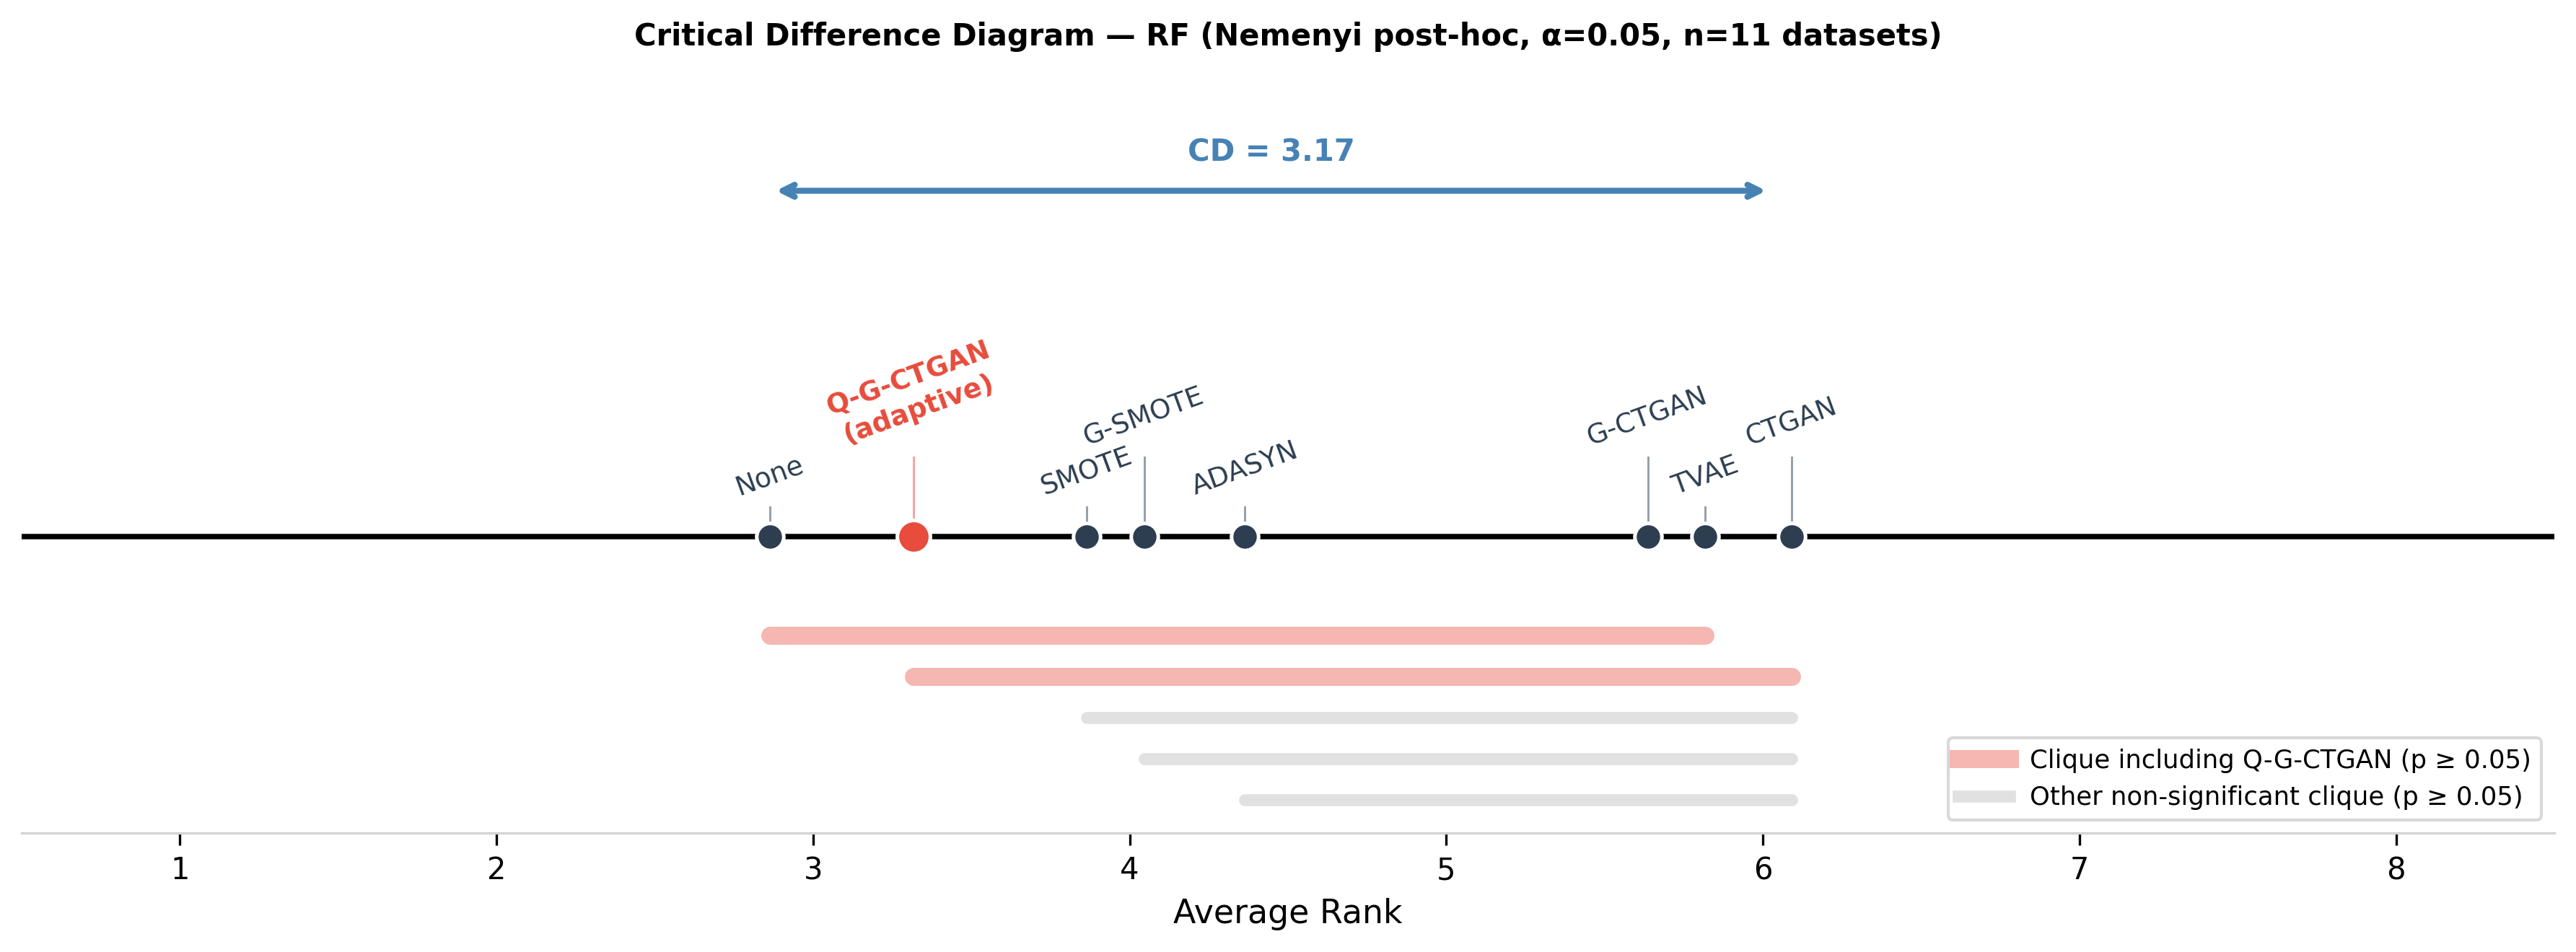


[LGBM] pivot_clean shape: (11, 8)
[LGBM] methods: ['None', 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'Q-G-CTGAN_adaptive']
[LGBM] n_methods=8  n_datasets=11  CD=3.166
Saved → ./results\04_cd_diagram_lgbm.png


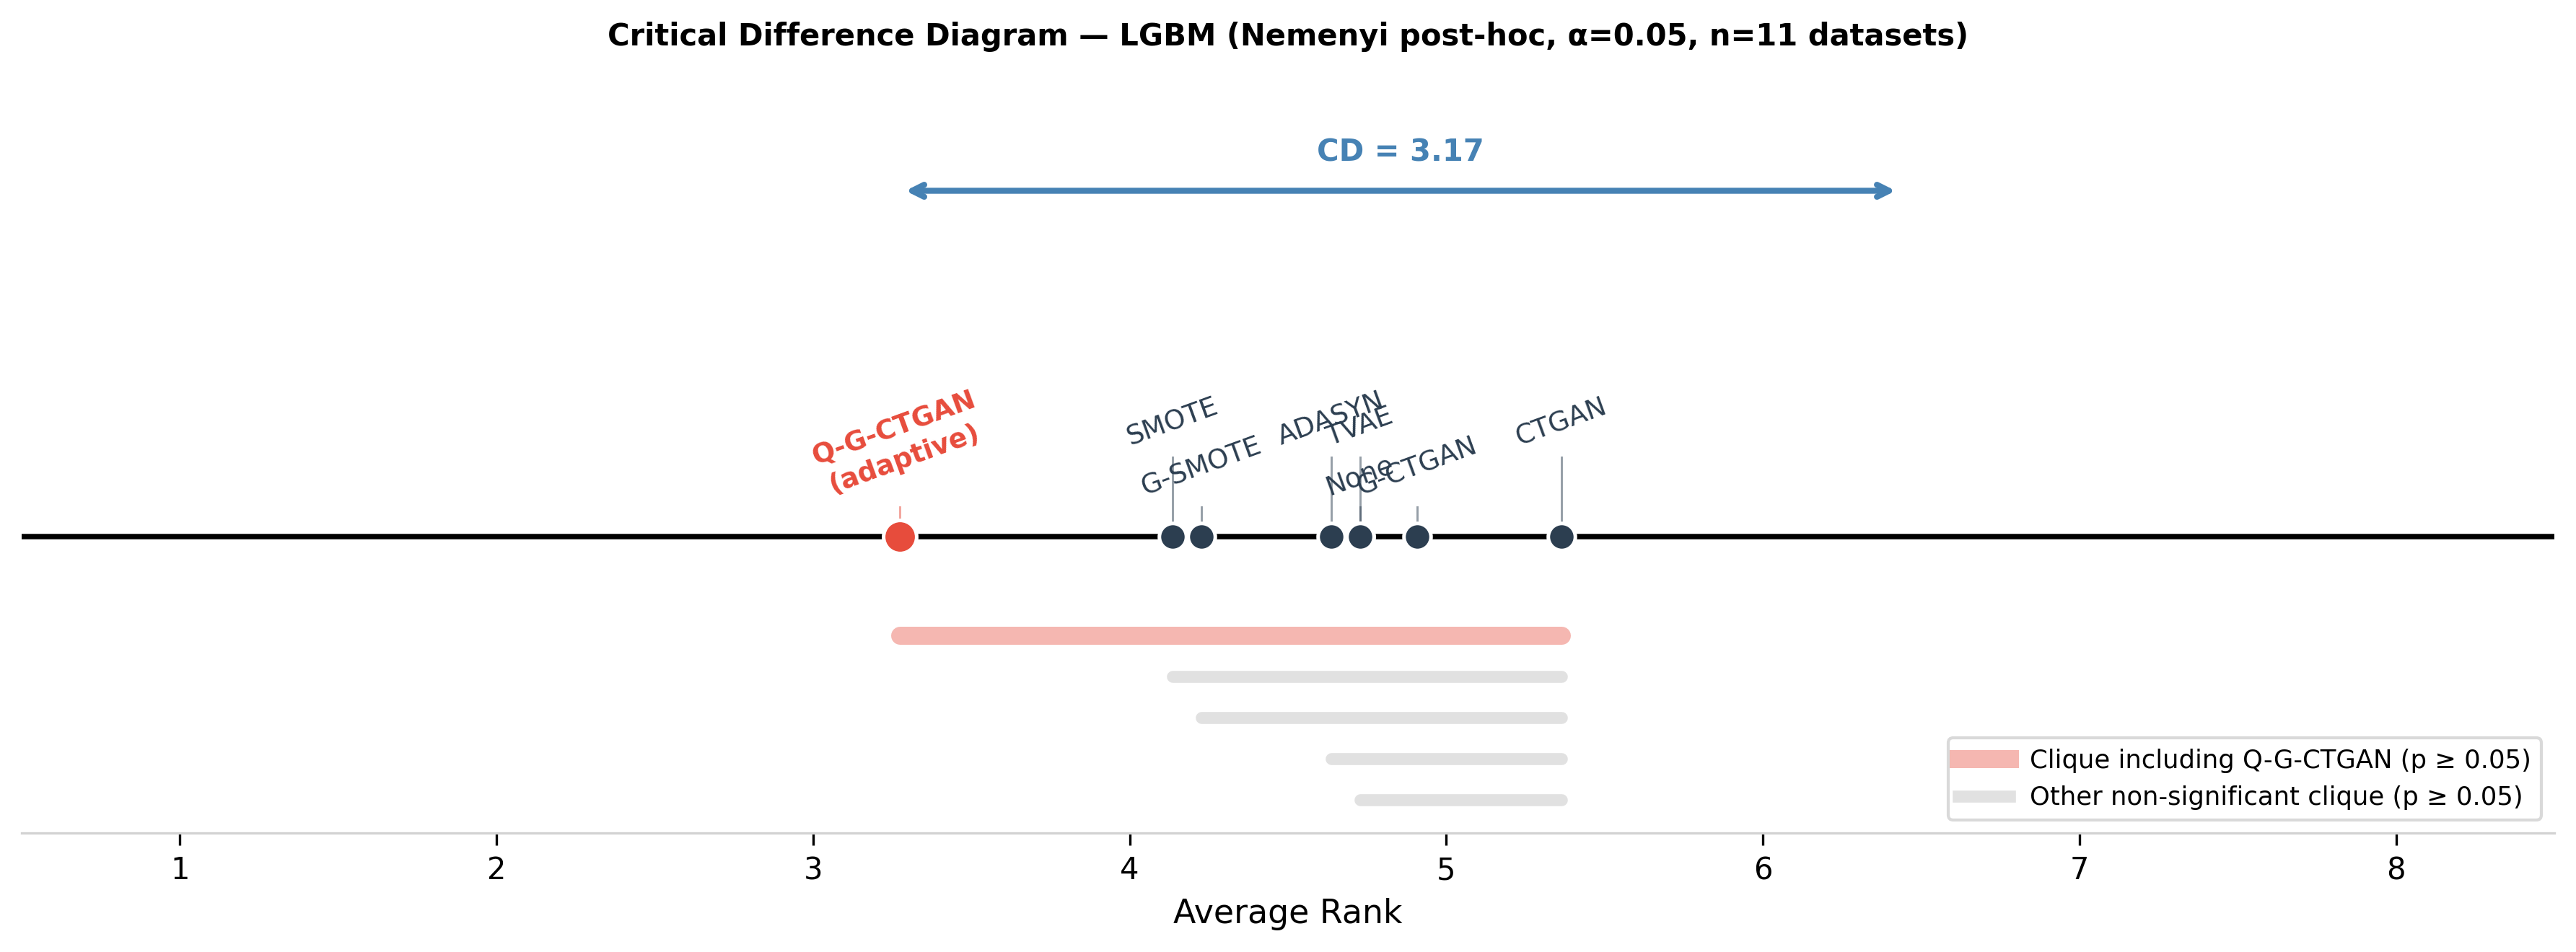


[MLP] pivot_clean shape: (11, 8)
[MLP] methods: ['None', 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE', 'G-CTGAN', 'Q-G-CTGAN_adaptive']
[MLP] n_methods=8  n_datasets=11  CD=3.166
Saved → ./results\04_cd_diagram_mlp.png


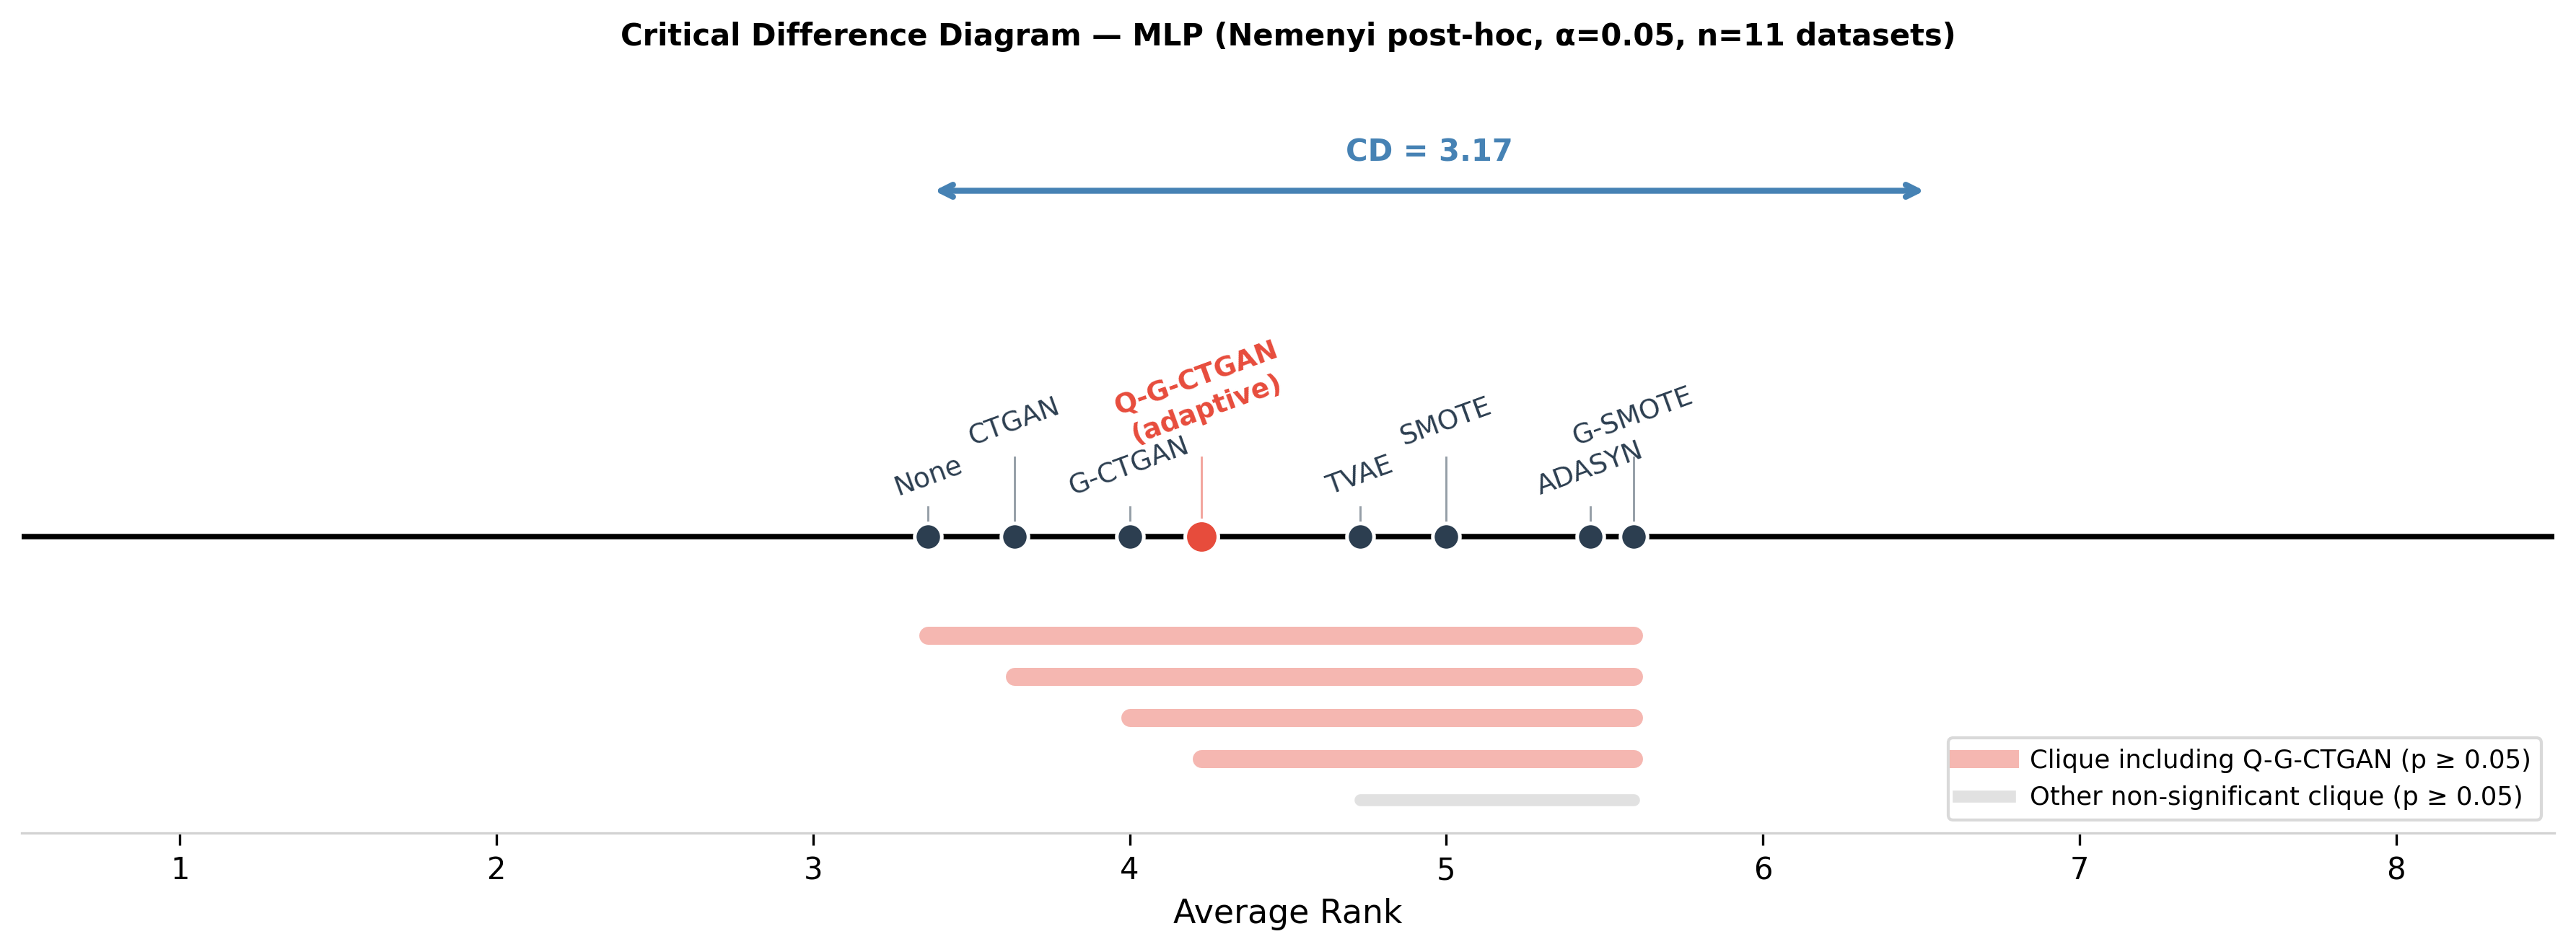

In [17]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scikit_posthocs import posthoc_nemenyi_friedman

warnings.filterwarnings("ignore")

mpl.rcParams.update({
    "figure.dpi"     : 300,
    "savefig.dpi"    : 300,
    "font.size"      : 10,
    "axes.labelsize" : 11,
    "xtick.labelsize": 10,
    "font.family"    : "sans-serif",
    "pdf.fonttype"   : 42,
    "ps.fonttype"    : 42,
})

RESULTS_DIR = "./results"
RANDOM_STATE = 42

DATASET_NAMES = [
    "credit_default", "fraud_detection", "pima_diabetes", "ibm_attrition",
    "yeast_me2", "mammography", "abalone_19", "wine_quality",
    "ecoli", "pageblocks", "protein_homo",
]

METHOD_ORDER = [
    "None", "SMOTE", "ADASYN", "G-SMOTE",
    "CTGAN", "TVAE", "G-CTGAN", "Q-G-CTGAN_adaptive",
]

METHOD_LABELS = {
    "None"               : "None",
    "SMOTE"              : "SMOTE",
    "ADASYN"             : "ADASYN",
    "G-SMOTE"            : "G-SMOTE",
    "CTGAN"              : "CTGAN",
    "TVAE"               : "TVAE",
    "G-CTGAN"            : "G-CTGAN",
    "Q-G-CTGAN_adaptive" : "Q-G-CTGAN\n(adaptive)",
}

CLASSIFIERS = ["RF", "LGBM", "MLP"]

# ── Load & merge ───────────────────────────────────────────
base_df  = pd.read_csv(os.path.join(RESULTS_DIR, "02_baselines_results.csv"))
qg_df    = pd.read_csv(os.path.join(RESULTS_DIR, "03_qgctgan_results.csv"))
qg_best  = qg_df[qg_df["oversampling"] == "Q-G-CTGAN_adaptive"].copy()
shared   = [c for c in base_df.columns if c in qg_best.columns]
combined = pd.concat([base_df[shared], qg_best[shared]], ignore_index=True)

# Fix: "None" stored as NaN
combined["oversampling"] = combined["oversampling"].fillna("None")

print(f"Methods : {combined['oversampling'].unique().tolist()}")


# ── CD Diagram function ────────────────────────────────────
def plot_cd_diagram(clf):
    sub = combined[combined["classifier"] == clf].copy()

    pivot = (
        sub.groupby(["dataset", "oversampling"])["AUC"]
        .mean().unstack()
        .reindex(index=DATASET_NAMES,
                 columns=[m for m in METHOD_ORDER
                           if m in sub["oversampling"].unique()])
        .dropna(axis=1, how="all")
    )
    pivot_clean = pivot.dropna()

    print(f"\n[{clf}] pivot_clean shape: {pivot_clean.shape}")
    print(f"[{clf}] methods: {pivot_clean.columns.tolist()}")

    # Nemenyi post-hoc
    nemenyi_raw = posthoc_nemenyi_friedman(pivot_clean.values)
    nemenyi = pd.DataFrame(
        nemenyi_raw.values,
        index=pivot_clean.columns,
        columns=pivot_clean.columns,
    )

    # Average ranks
    ranks        = pivot_clean.rank(axis=1, ascending=False).mean()
    ranks_sorted = ranks.sort_values()
    n_methods    = len(ranks_sorted)
    n_datasets   = len(pivot_clean)

    # Critical difference
    q_alpha_table = {
        2:1.960, 3:2.343, 4:2.569, 5:2.728,
        6:2.850, 7:2.949, 8:3.031, 9:3.102, 10:3.164
    }
    q_alpha = q_alpha_table.get(n_methods, 3.164)
    CD = q_alpha * np.sqrt(n_methods * (n_methods + 1) / (6 * n_datasets))

    print(f"[{clf}] n_methods={n_methods}  n_datasets={n_datasets}  CD={CD:.3f}")

    # ── Figure ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 4.5))

    ax.set_xlim(0.5, n_methods + 0.5)
    ax.set_ylim(-1.8, 2.8)
    ax.set_xlabel("Average Rank", fontsize=11)
    ax.set_xticks(range(1, n_methods + 1))
    ax.axhline(0, color="black", linewidth=1.8, zorder=3)
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color("lightgray")
    ax.tick_params(axis="x", labelsize=10, length=4)

    # Markers & alternating labels
    for idx, (method, rank) in enumerate(ranks_sorted.items()):
        is_ours   = method == "Q-G-CTGAN_adaptive"
        color     = "#E74C3C" if is_ours else "#2C3E50"
        ms        = 11 if is_ours else 9
        y_offset  = 0.22 + 0.30 * (idx % 2)
        label     = METHOD_LABELS.get(method, method)

        ax.plot(rank, 0, "o",
                color=color, markersize=ms, zorder=5,
                markeredgecolor="white", markeredgewidth=1.2)

        ax.text(rank, y_offset, label,
                ha="center", va="bottom",
                fontsize=9, color=color,
                fontweight="bold" if is_ours else "normal",
                rotation=20, linespacing=1.3)

        ax.plot([rank, rank], [0.02, y_offset - 0.04],
                color=color, linewidth=0.7, alpha=0.5, zorder=2)

    # CD bracket from best rank
    rank_min = ranks_sorted.iloc[0]
    ax.annotate("",
                xy=(rank_min + CD, 2.1),
                xytext=(rank_min, 2.1),
                arrowprops=dict(arrowstyle="<->",
                                color="steelblue", lw=2.0))
    ax.text(rank_min + CD / 2, 2.28,
            f"CD = {CD:.2f}",
            ha="center", fontsize=10,
            color="steelblue", fontweight="bold")

    # Clique bars
    y_clique = -0.60
    drawn    = set()
    for m1 in ranks_sorted.index:
        clique = []
        for m2 in ranks_sorted.index:
            if (m1, m2) not in drawn and nemenyi.loc[m1, m2] >= 0.05:
                clique.append(m2)
                drawn.add((m1, m2))
                drawn.add((m2, m1))
        if len(clique) > 1:
            clique_ranks  = [ranks_sorted[m] for m in clique]
            contains_ours = "Q-G-CTGAN_adaptive" in clique
            bar_color     = "#E74C3C" if contains_ours else "#AAAAAA"
            bar_alpha     = 0.40     if contains_ours else 0.35
            bar_lw        = 6        if contains_ours else 4
            ax.plot([min(clique_ranks), max(clique_ranks)],
                    [y_clique, y_clique],
                    color=bar_color, linewidth=bar_lw,
                    alpha=bar_alpha, zorder=3,
                    solid_capstyle="round")
            y_clique -= 0.25

    # Legend
    legend_elements = [
        Line2D([0],[0], color="#E74C3C", linewidth=6, alpha=0.40,
               label="Clique including Q-G-CTGAN (p ≥ 0.05)"),
        Line2D([0],[0], color="#AAAAAA", linewidth=4, alpha=0.35,
               label="Other non-significant clique (p ≥ 0.05)"),
    ]
    ax.legend(handles=legend_elements, fontsize=8.5,
              loc="lower right", framealpha=0.85,
              edgecolor="lightgray")

    ax.set_title(
        f"Critical Difference Diagram — {clf} "
        f"(Nemenyi post-hoc, α=0.05, n={n_datasets} datasets)",
        fontsize=10, fontweight="bold", pad=10
    )

    plt.tight_layout()

    out = os.path.join(RESULTS_DIR, f"04_cd_diagram_{clf.lower()}.png")
    fig.savefig(out, dpi=300, bbox_inches="tight")
    fig.savefig(out.replace(".png", ".pdf"), bbox_inches="tight")
    print(f"Saved → {out}")
    plt.show()


# ── Run for all classifiers ────────────────────────────────
for clf in CLASSIFIERS:
    plot_cd_diagram(clf)

In [18]:
import os
import shutil

RESULTS_DIR = "./results"

RENAME_MAP = {
    "04_figure3_adaptive_alpha" : "fig04_adaptive_alpha",
    "04_figure4_tsne"           : "fig05_tsne_before_after",
    "04_auc_heatmap"            : "fig06_auc_heatmap",
    "04_cd_diagram_rf"          : "fig07_cd_diagram_rf",
    "04_cd_diagram_lgbm"        : "fig08_cd_diagram_lgbm",
    "04_cd_diagram_mlp"         : "fig09_cd_diagram_mlp",
    "04_ablation_quality"       : "fig10_ablation_quality",
    "04_mmd_summary"            : "fig11_mmd_summary",
}

for old_name, new_name in RENAME_MAP.items():
    for ext in [".png", ".pdf"]:
        old_path = os.path.join(RESULTS_DIR, old_name + ext)
        new_path = os.path.join(RESULTS_DIR, new_name + ext)
        if os.path.exists(old_path):
            shutil.copy2(old_path, new_path)
            print(f"✓  {old_name + ext}  →  {new_name + ext}")
        else:
            print(f"✗  {old_name + ext}  — (skip)")

✓  04_figure3_adaptive_alpha.png  →  fig04_adaptive_alpha.png
✗  04_figure3_adaptive_alpha.pdf  — (skip)
✓  04_figure4_tsne.png  →  fig05_tsne_before_after.png
✗  04_figure4_tsne.pdf  — (skip)
✓  04_auc_heatmap.png  →  fig06_auc_heatmap.png
✗  04_auc_heatmap.pdf  — (skip)
✓  04_cd_diagram_rf.png  →  fig07_cd_diagram_rf.png
✓  04_cd_diagram_rf.pdf  →  fig07_cd_diagram_rf.pdf
✓  04_cd_diagram_lgbm.png  →  fig08_cd_diagram_lgbm.png
✓  04_cd_diagram_lgbm.pdf  →  fig08_cd_diagram_lgbm.pdf
✓  04_cd_diagram_mlp.png  →  fig09_cd_diagram_mlp.png
✓  04_cd_diagram_mlp.pdf  →  fig09_cd_diagram_mlp.pdf
✓  04_ablation_quality.png  →  fig10_ablation_quality.png
✗  04_ablation_quality.pdf  — (skip)
✓  04_mmd_summary.png  →  fig11_mmd_summary.png
✗  04_mmd_summary.pdf  — (skip)
